In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

In [2]:
# TODO: change name if needed
name = "Mrk501"
blazar_coord = SkyCoord.from_name(name)
# TODO: change data_folder if needed
data_folder = "../cta_dc_data/mrk_501/"
data_folder_40deg = data_folder+"40deg/"
data_folder_20deg = data_folder+"20deg/"
irf_file_40deg = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irf_file_20deg = "../cta_dc_data/irfs/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus_40deg = []
hbus_20deg = []
for filename in os.listdir(data_folder_40deg):
    hbus_40deg.append(fits.open(data_folder_40deg + filename))
for filename in os.listdir(data_folder_20deg):
    hbus_20deg.append(fits.open(data_folder_20deg + filename))
    
irf_40deg = load_irf_dict_from_file(irf_file_40deg)
irf_20deg = load_irf_dict_from_file(irf_file_20deg)
print(f"Pointings 40deg: {len(hbus_40deg)}")
print(f"Pointings 20deg: {len(hbus_20deg)}")

Pointings 40deg: 60
Pointings 20deg: 66


In [4]:
e_bins=np.logspace(np.log10(0.01), np.log10(100), 15)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

#th2_bins=np.linspace(0,0.16,17)
th2_bins=np.linspace(0,0.16,34)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [11]:
def collect_data(hbus):
    cts_s = np.zeros((len(e), len(th2)))
    cts_b = np.zeros((len(e), len(th2)))
    t_expo = 0

    for hbu in hbus:
        data_raw = hbu["EVENTS"].data
    
        t = data_raw["TIME"]
        t = np.sort(t)
        t_expo += t[-1] - t[0]
    
        coord = SkyCoord(
            ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
        )
    
        pointing_coord = SkyCoord(
            ra=hbu[1].header["RA_PNT"] * u.deg,
            dec=hbu[1].header["DEC_PNT"] * u.deg,
            frame="icrs",
        )
    
        bkg_center = SkyCoord(
            l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
            b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
            frame="galactic",
        )

        seps = coord.separation(blazar_coord).degree
        seps_b = coord.separation(bkg_center).degree
        src_pos_mask = seps < bkg_subtraction_radius
        bkg_pos_mask = seps_b < bkg_subtraction_radius
    
        energ = data_raw["ENERGY"]
    
        for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
            m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
            m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask
    
            h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
            h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
            
            cts_s[i] += h_s
            cts_b[i] += h_b
    
    return cts_s, cts_b, t_expo

In [9]:
pointing_sep_avg = 0

for hbu in hbus_40deg:
    data_raw = hbu["EVENTS"].data

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )
    
    pointing_sep = pointing_coord.separation(blazar_coord).degree
    pointing_sep_avg += pointing_sep

pointing_sep_avg /= len(hbus_40deg)
print(pointing_sep_avg)

0.7000000000094391


In [12]:
bkg_subtraction_radius = pointing_sep_avg

cts_s_40deg, cts_b_40deg, t_expo_40deg = collect_data(hbus_40deg)
cts_s_20deg, cts_b_20deg, t_expo_20deg = collect_data(hbus_20deg)

print(f"Exposure time 40deg = {t_expo_40deg/60/60:.1f}h")
print(f"Exposure time 20deg = {t_expo_20deg/60/60:.1f}h")

Exposure time 40deg = 8.5h
Exposure time 20deg = 9.3h


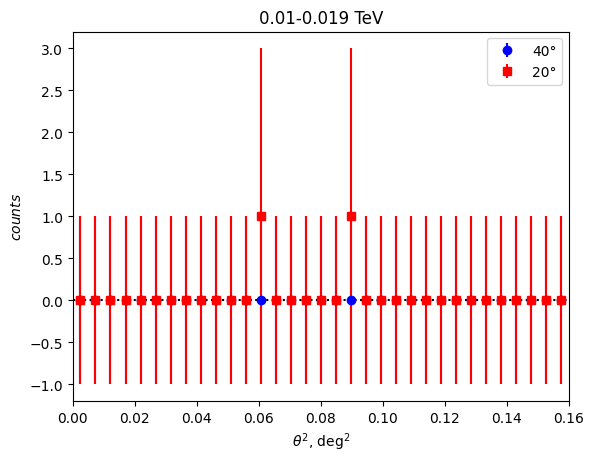

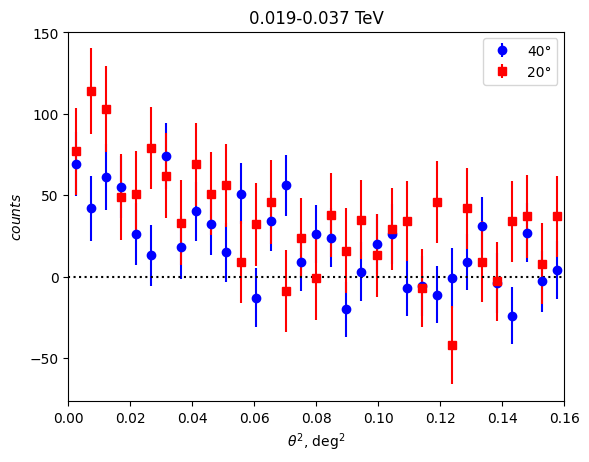

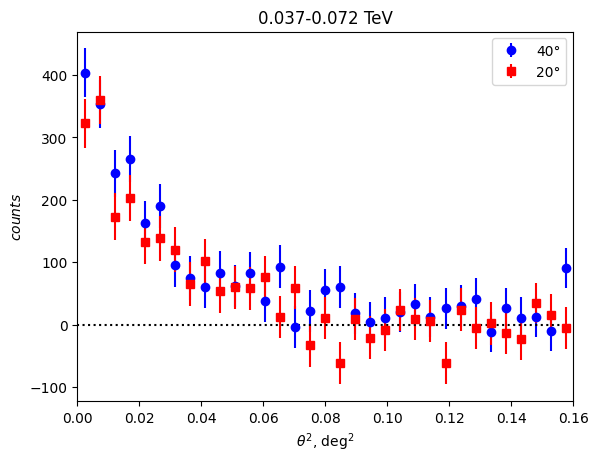

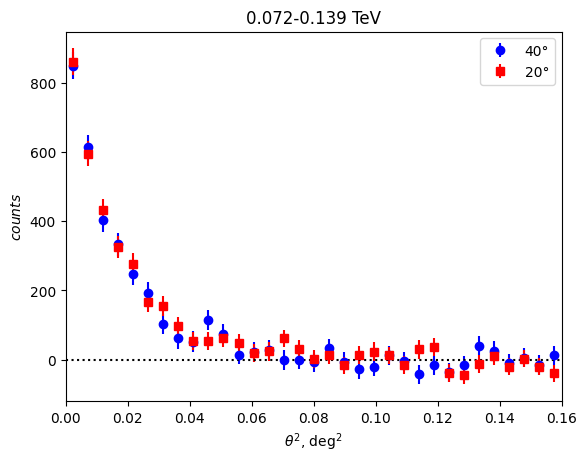

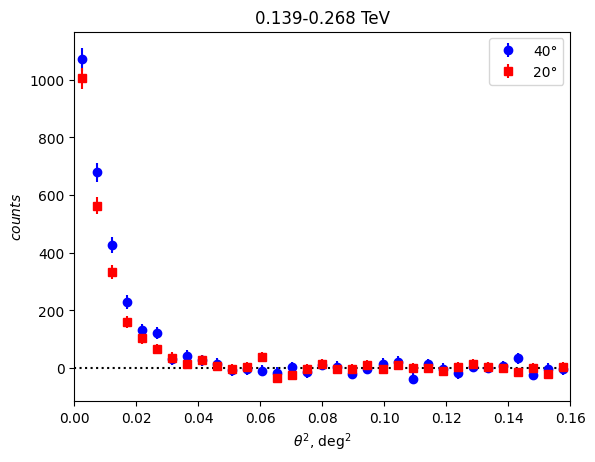

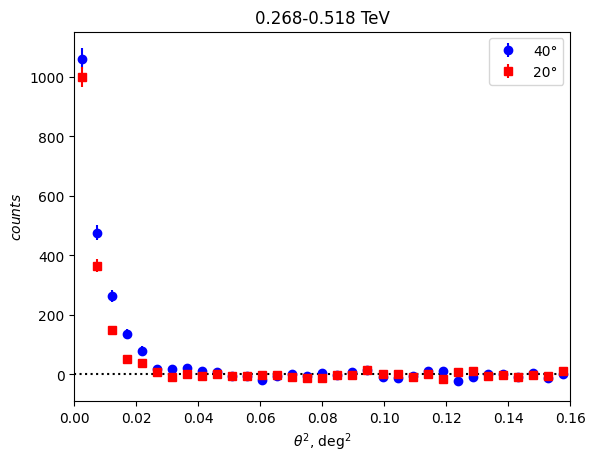

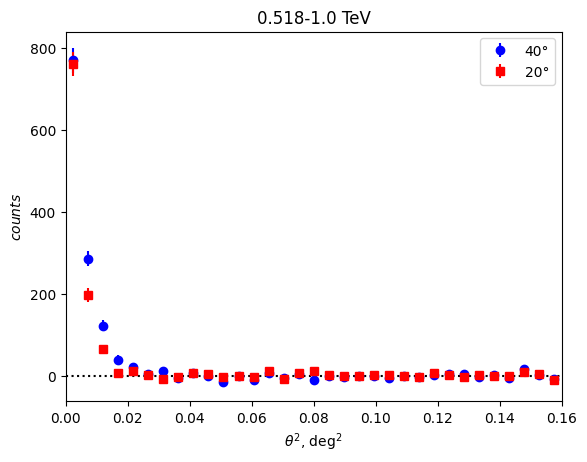

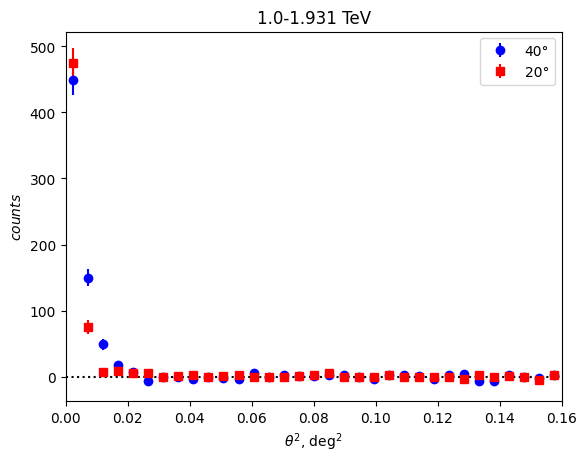

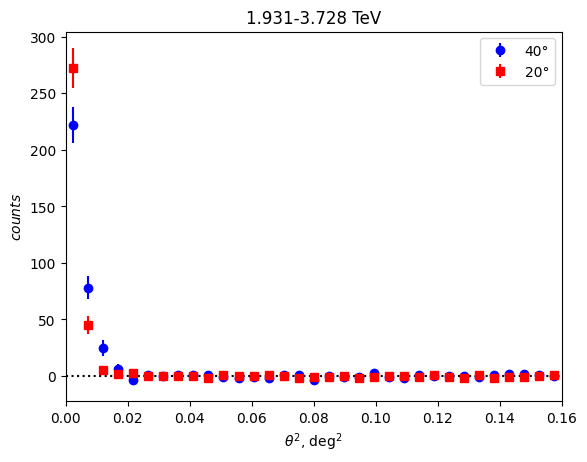

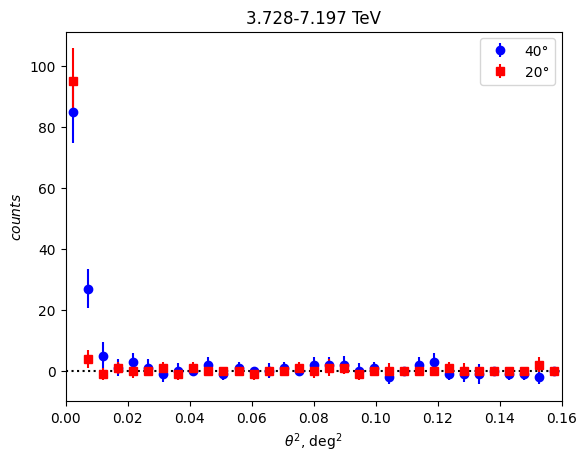

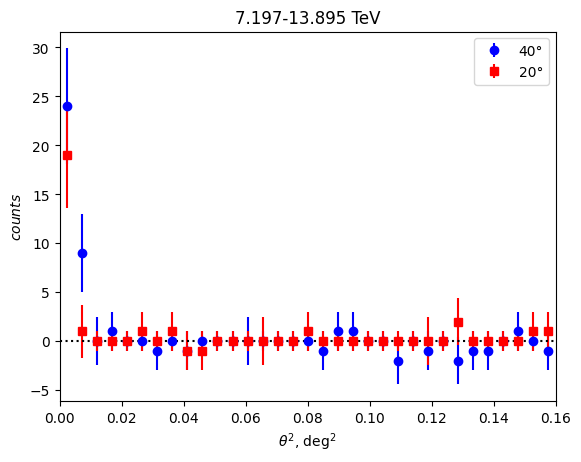

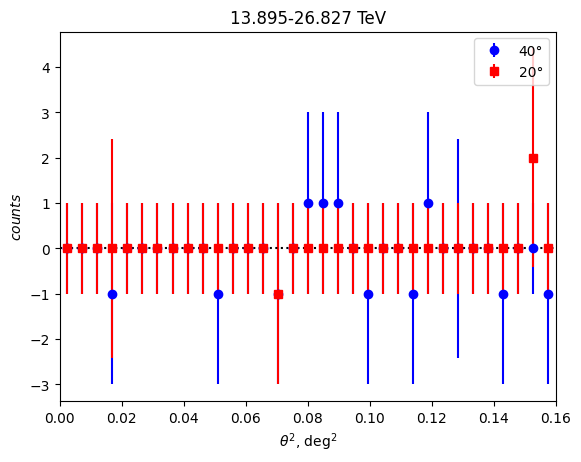

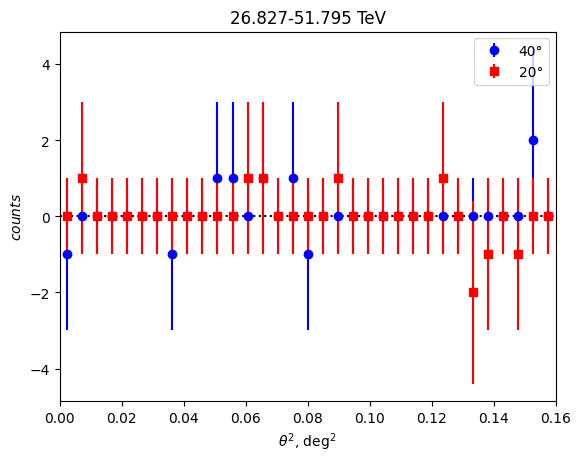

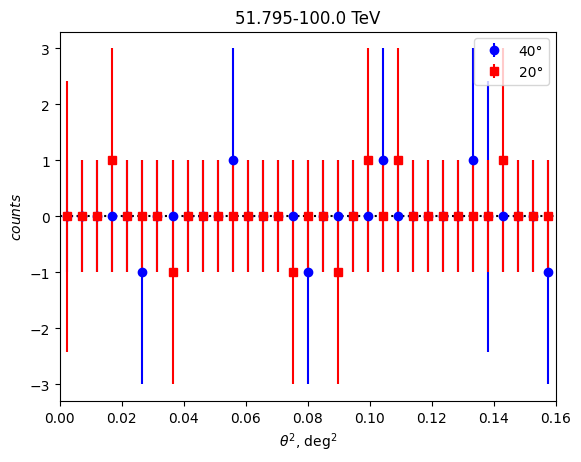

In [13]:
cts_40deg = cts_s_40deg - cts_b_40deg
cts_err_40deg = 1 + np.sqrt(cts_s_40deg + cts_b_40deg)

cts_20deg = cts_s_20deg - cts_b_20deg
cts_err_20deg = 1 + np.sqrt(cts_s_20deg + cts_b_20deg)

for i, ((cts_40, cts_err_40), (cts_20, cts_err_20)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
    plt.figure()
    plt.errorbar(th2, cts_40, cts_err_40, fmt='o', label='40°', color='blue')
    plt.errorbar(th2, cts_20, cts_err_20, fmt='s', label='20°', color='red')
    plt.axhline(0, color='black', linestyle='dotted')
    plt.xlim(0, 0.16)
    plt.title(str(round(e_mins[i],3)) + '-' + str(round(e_maxs[i],3)) + ' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.legend()
    plt.show()

**PSF**

In [14]:
psf_hbu_40deg = irf_40deg["psf"]
psf_hbu_20deg = irf_20deg["psf"]

print(psf_hbu_40deg)
print(psf_hbu_40deg.info())
print(psf_hbu_40deg.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

**UP Limits**

In [9]:
sigmas_ext = np.linspace(0.05, pointing_sep_avg, 10)

In [10]:
def calculate_UL(cts, cts_err, psf_hbu):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))

    for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]
    
        # Normalization of the PSF model to fit best the blazar
        def psf_model(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1**2))
            gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
            gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
            return (gauss1+gauss2+gauss3)

        # rescaling the psf component to match total counts of the data
        psf_component = psf_model(th2)
        psf_component = sum(ct)*psf_component/sum(psf_component)
        # The errors on the counts are independent, here I used this formula for error propagation:
        # z = \sum x_i, then z_err = sqrt(\sum x_i_err**2)
        # psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
        # Lets try without error
        psf_component_err = np.zeros_like(psf_component)
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
        # taken from andrii notebook, to fit with psf better:
        step=1.01
        chi2_noext_best=1e10
        adjust=1
        while(chi2_noext<chi2_noext_best):
            chi2_noext_best=chi2_noext
            
            chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(step*adjust*psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
            chisq_vec=np.array([chisq0,chisq1])
            chi2_noext=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            
            if(chi2_noext<chi2_noext_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                    
        psf_component *= adjust
        psf_component_err *= adjust
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

        psf_component_noext_best = psf_component
        psf_component_err_noext_best = psf_component_err
        
        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            psf_component = psf_component_noext_best
            psf_component_err = psf_component_err_noext_best
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                c1 = sigma_1/(sigma_1**2 + sigma_ext**2)
                c2 = ampl_2*sigma_2/(sigma_2**2 + sigma_ext**2)
                c3 = ampl_3*sigma_3/(sigma_3**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return gauss1_conv + gauss2_conv + gauss3_conv
        
            ct_ext = ext_model(th2)
            print(f"ext_model sum = {sum(ct_ext)}")
            ct_ext = sum(ct)*ct_ext/sum(ct_ext)
            print(f"after normalization sum = {sum(ct_ext)}")
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))

            # Finding the best fit for psf*(extended + point)
            step=1.01
            chi2_ext_best = 1e10
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best):
                chi2_ext_best = chi2_ext
                #ct_ext_err*=adjust_ext for the moment without error
                
                chisq0=sum((ct-step*adjust_point*psf_component-adjust_ext*ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                chisq1=sum((ct-adjust_point*psf_component/step-adjust_ext*ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                chisq2=sum((ct-adjust_point*psf_component-step*adjust_ext*ct_ext)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq3=sum((ct-adjust_point*psf_component-adjust_ext*ct_ext/step)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
                chi2_ext=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                
                if(chi2_ext<chi2_ext_best):
                    if(ind==0):
                        adjust_point*=step
                    if(ind==1):
                        adjust_point/=step
                    if(ind==2):
                        adjust_ext*=step
                    if(ind==3):
                        adjust_ext/=step

            ct_ext*=adjust_ext
            psf_component*=adjust_point
            psf_component_err*=adjust_point
            
            cts_tot_best = np.sum(ct_ext + psf_component)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            # Here chi2_ext is chi2_min, the best fit possible.
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")
            axs[0].plot(th2,ct_ext,color='red',alpha=0.5,marker='+', linestyle="none",label='extended source best fit')

            # Upper limits
            # We fix the extended normalization and keep the other parameters free. delta dof = 1.
            # We finish at chi2 - chi2_min \approx 2.71
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                # extended normalization fixed ...
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                # ... while we fit best with other parameters:
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratios[k][i] = np.sum(ct_ext)/cts_tot_best
            axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios

ext_model sum = 55.34508678834268
after normalization sum = 5.999999999999998
Best fit extended plus point gives chi2: 1.446766965194126
ext_model sum = 53.14643456992528
after normalization sum = 6.000000000000001
Best fit extended plus point gives chi2: 1.4264187654408669
ext_model sum = 48.5013552802046
after normalization sum = 5.999999999999999
Best fit extended plus point gives chi2: 1.4018698388905837
ext_model sum = 42.134870084161555
after normalization sum = 6.0000000000000036
Best fit extended plus point gives chi2: 1.3819128542388828
ext_model sum = 35.492060902018515
after normalization sum = 5.999999999999999
Best fit extended plus point gives chi2: 1.368529452406241
ext_model sum = 29.51305310116192
after normalization sum = 6.0
Best fit extended plus point gives chi2: 1.3600526689551653
ext_model sum = 24.508744309714782
after normalization sum = 6.0
Best fit extended plus point gives chi2: 1.3546412156021066
ext_model sum = 20.452869042522114
after normalization sum = 

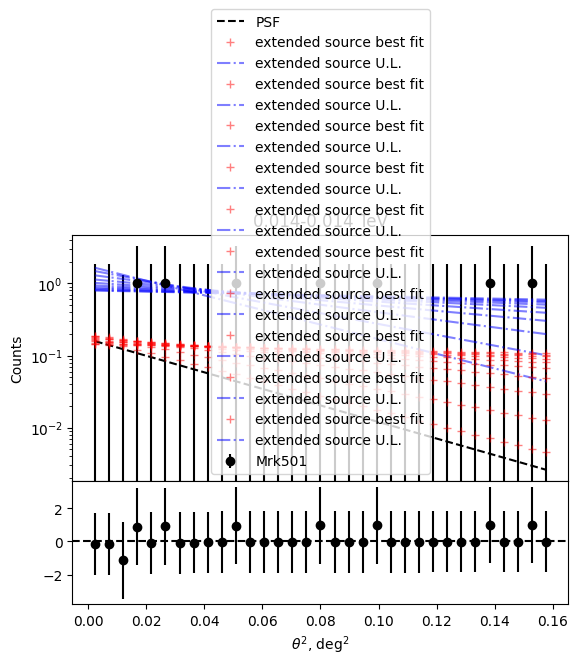

ext_model sum = 52.85398176239406
after normalization sum = 846.0
Best fit extended plus point gives chi2: 34.35248512969002
ext_model sum = 50.982009922626354
after normalization sum = 846.0
Best fit extended plus point gives chi2: 33.58445274484081
ext_model sum = 46.67459339760533
after normalization sum = 845.9999999999995
Best fit extended plus point gives chi2: 33.74922837336793
ext_model sum = 40.55997820987865
after normalization sum = 846.0
Best fit extended plus point gives chi2: 33.95047892353038
ext_model sum = 34.11684368225398
after normalization sum = 845.9999999999998
Best fit extended plus point gives chi2: 34.104049394684026
ext_model sum = 28.31487031916621
after normalization sum = 845.9999999999999
Best fit extended plus point gives chi2: 34.21260806809192
ext_model sum = 23.470180799847775
after normalization sum = 846.0000000000002
Best fit extended plus point gives chi2: 34.28948202420168
ext_model sum = 19.554935433094258
after normalization sum = 845.999999999

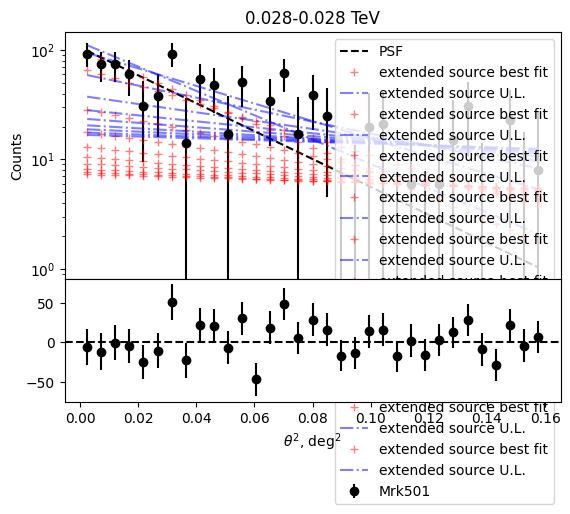

ext_model sum = 42.97876992398321
after normalization sum = 2892.0
Best fit extended plus point gives chi2: 24.65366184307546
ext_model sum = 42.179647531933746
after normalization sum = 2891.9999999999986
Best fit extended plus point gives chi2: 23.28043861625064
ext_model sum = 39.195645999363045
after normalization sum = 2892.0
Best fit extended plus point gives chi2: 21.8745214505988
ext_model sum = 34.17277151419692
after normalization sum = 2891.9999999999995
Best fit extended plus point gives chi2: 21.07004680398471
ext_model sum = 28.630254467385658
after normalization sum = 2892.0
Best fit extended plus point gives chi2: 20.65457139627944
ext_model sum = 23.615210285555982
after normalization sum = 2891.9999999999995
Best fit extended plus point gives chi2: 20.45343085146643
ext_model sum = 19.45661945401838
after normalization sum = 2892.0
Best fit extended plus point gives chi2: 20.33799369874089
ext_model sum = 16.126628095788153
after normalization sum = 2891.999999999998


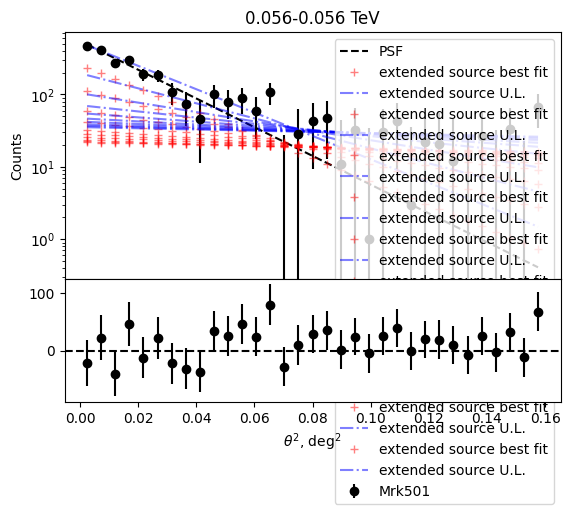

ext_model sum = 36.344340031500494
after normalization sum = 3338.9999999999986
Best fit extended plus point gives chi2: 36.13134458030716
ext_model sum = 36.00818392923035
after normalization sum = 3338.999999999999
Best fit extended plus point gives chi2: 36.1313445803076
ext_model sum = 33.8334610727633
after normalization sum = 3339.0000000000014
Best fit extended plus point gives chi2: 36.131344580307626
ext_model sum = 29.603732037596163
after normalization sum = 3339.0000000000014
Best fit extended plus point gives chi2: 36.13134458030782
ext_model sum = 24.762487873372933
after normalization sum = 3339.0000000000005
Best fit extended plus point gives chi2: 36.13134458030747
ext_model sum = 20.359286520454766
after normalization sum = 3339.0000000000014
Best fit extended plus point gives chi2: 36.13134458030777
ext_model sum = 16.719648677154446
after normalization sum = 3339.0
Best fit extended plus point gives chi2: 36.13134458030763
ext_model sum = 13.81924533966022
after nor

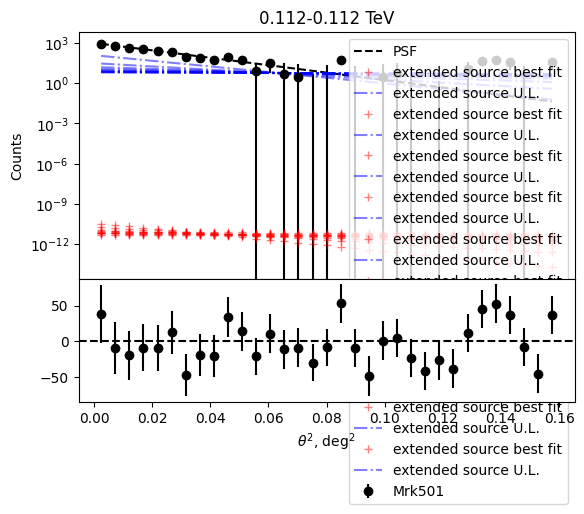

ext_model sum = 26.703910973129506
after normalization sum = 2576.0
Best fit extended plus point gives chi2: 31.59537379528893
ext_model sum = 26.71876715041957
after normalization sum = 2576.0
Best fit extended plus point gives chi2: 31.570114542712236
ext_model sum = 25.492504591298847
after normalization sum = 2576.0
Best fit extended plus point gives chi2: 31.570114542712453
ext_model sum = 22.445031331267025
after normalization sum = 2576.0000000000005
Best fit extended plus point gives chi2: 31.570114542712336
ext_model sum = 18.7506731738828
after normalization sum = 2576.0000000000005
Best fit extended plus point gives chi2: 31.570114542712446
ext_model sum = 15.360296914751565
after normalization sum = 2575.9999999999995
Best fit extended plus point gives chi2: 31.57011454271297
ext_model sum = 12.566588701309803
after normalization sum = 2576.0000000000005
Best fit extended plus point gives chi2: 31.570114542713103
ext_model sum = 10.352560133975556
after normalization sum = 

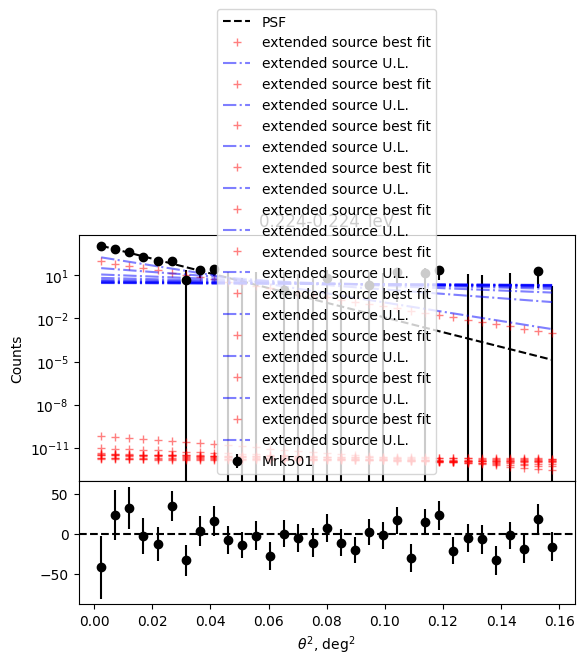

ext_model sum = 23.65304797964721
after normalization sum = 1924.9999999999995
Best fit extended plus point gives chi2: 45.97586399368301
ext_model sum = 23.731725600958008
after normalization sum = 1925.0
Best fit extended plus point gives chi2: 45.97586399368441
ext_model sum = 22.738203336872413
after normalization sum = 1924.9999999999998
Best fit extended plus point gives chi2: 45.97586399368508
ext_model sum = 20.06018142549367
after normalization sum = 1925.0
Best fit extended plus point gives chi2: 45.97586399368434
ext_model sum = 16.754957840705547
after normalization sum = 1925.0000000000005
Best fit extended plus point gives chi2: 45.9758639936842
ext_model sum = 13.712880408516327
after normalization sum = 1924.9999999999998
Best fit extended plus point gives chi2: 45.97586399368352
ext_model sum = 11.207893176670236
after normalization sum = 1924.9999999999998
Best fit extended plus point gives chi2: 45.9758639936837
ext_model sum = 9.225446289550808
after normalization s

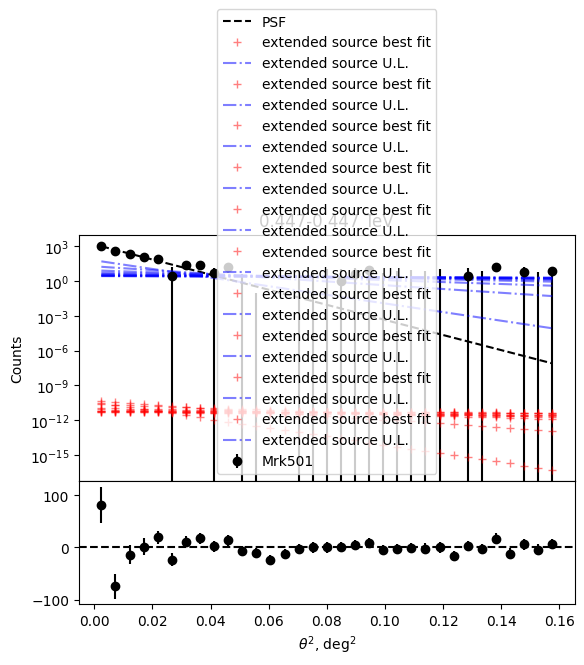

ext_model sum = 20.14307017972924
after normalization sum = 1037.0000000000005
Best fit extended plus point gives chi2: 21.32363522433606
ext_model sum = 20.28158412052123
after normalization sum = 1037.0
Best fit extended plus point gives chi2: 21.323635224336222
ext_model sum = 19.516445617910378
after normalization sum = 1037.0000000000002
Best fit extended plus point gives chi2: 21.323635224336407
ext_model sum = 17.255883729578795
after normalization sum = 1037.0000000000002
Best fit extended plus point gives chi2: 21.323635224336364
ext_model sum = 14.410577068540809
after normalization sum = 1036.9999999999998
Best fit extended plus point gives chi2: 21.323635224336744
ext_model sum = 11.783390482931951
after normalization sum = 1037.0000000000002
Best fit extended plus point gives chi2: 21.323635224337295
ext_model sum = 9.621426962852192
after normalization sum = 1037.0000000000002
Best fit extended plus point gives chi2: 21.32363522433653
ext_model sum = 7.912839991158575
aft

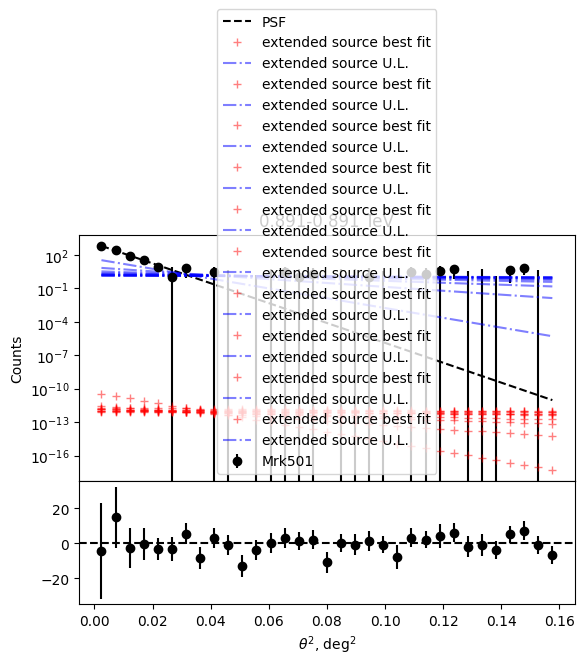

ext_model sum = 19.318251590286557
after normalization sum = 523.9999999999999
Best fit extended plus point gives chi2: 21.316080738580546
ext_model sum = 19.46918491670375
after normalization sum = 524.0
Best fit extended plus point gives chi2: 21.31608073858045
ext_model sum = 18.751979911368043
after normalization sum = 524.0000000000005
Best fit extended plus point gives chi2: 21.31608073858062
ext_model sum = 16.58815795241337
after normalization sum = 524.0000000000001
Best fit extended plus point gives chi2: 21.31608073858061
ext_model sum = 13.852621232083438
after normalization sum = 524.0
Best fit extended plus point gives chi2: 21.316080738581192
ext_model sum = 11.324968848493567
after normalization sum = 524.0
Best fit extended plus point gives chi2: 21.316080738581256
ext_model sum = 9.24518278131585
after normalization sum = 524.0000000000001
Best fit extended plus point gives chi2: 21.31608073858081
ext_model sum = 7.602027565365889
after normalization sum = 524.0000000

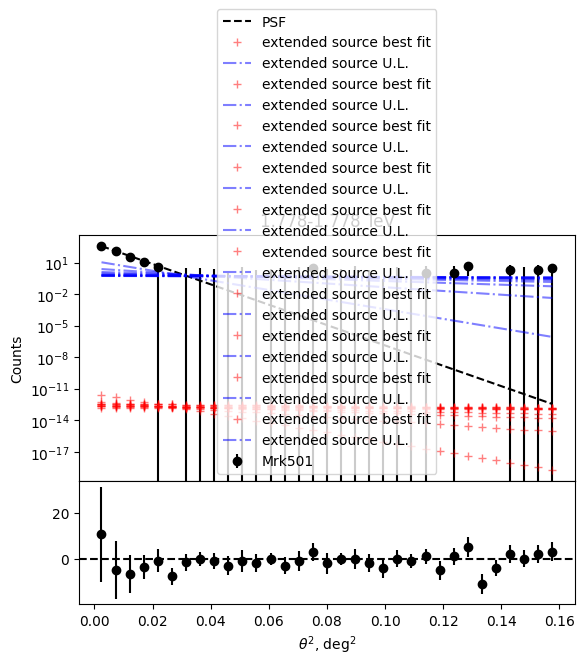

ext_model sum = 18.263301645664757
after normalization sum = 240.0000000000001
Best fit extended plus point gives chi2: 11.414654262622282
ext_model sum = 18.429228798855533
after normalization sum = 239.99999999999991
Best fit extended plus point gives chi2: 11.467152359538286
ext_model sum = 17.77035410054751
after normalization sum = 240.00000000000003
Best fit extended plus point gives chi2: 11.444106967381943
ext_model sum = 15.729477534604424
after normalization sum = 239.9999999999999
Best fit extended plus point gives chi2: 11.410957918110407
ext_model sum = 13.135211216897199
after normalization sum = 239.99999999999991
Best fit extended plus point gives chi2: 11.389899040624808
ext_model sum = 10.735938233277201
after normalization sum = 240.00000000000003
Best fit extended plus point gives chi2: 11.378637346370759
ext_model sum = 8.762089310427038
after normalization sum = 239.99999999999991
Best fit extended plus point gives chi2: 11.37249895284272
ext_model sum = 7.2031946

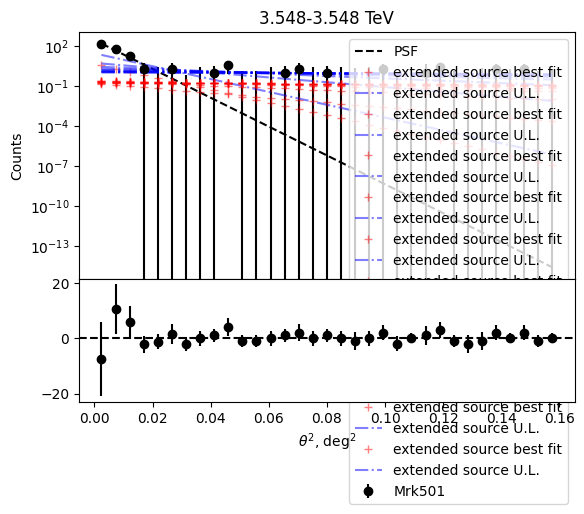

ext_model sum = 17.5409407180446
after normalization sum = 86.00000000000006
Best fit extended plus point gives chi2: 4.73450848816051
ext_model sum = 17.71652035349028
after normalization sum = 86.00000000000004
Best fit extended plus point gives chi2: 4.558774973733979
ext_model sum = 17.095731741530628
after normalization sum = 86.0
Best fit extended plus point gives chi2: 4.555226980566043
ext_model sum = 15.138531880501663
after normalization sum = 85.99999999999997
Best fit extended plus point gives chi2: 4.627227764746971
ext_model sum = 12.641548840576792
after normalization sum = 86.0
Best fit extended plus point gives chi2: 4.688766521478036
ext_model sum = 10.33086314770477
after normalization sum = 85.99999999999999
Best fit extended plus point gives chi2: 4.72899578782536
ext_model sum = 8.43008191518375
after normalization sum = 85.99999999999999
Best fit extended plus point gives chi2: 4.75430272201168
ext_model sum = 6.929248758029073
after normalization sum = 85.999999

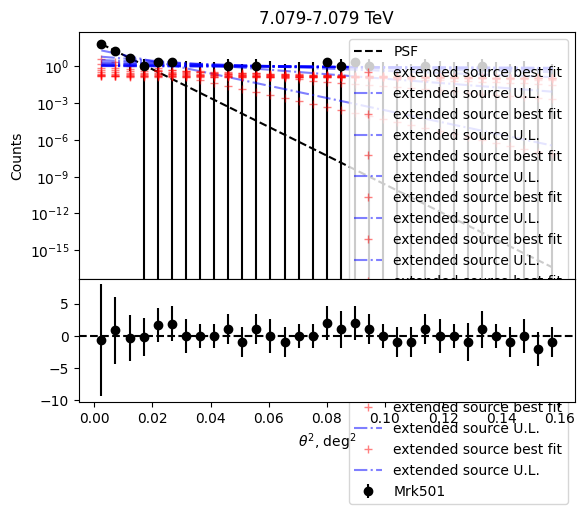

ext_model sum = 69.0109101794082
after normalization sum = 17.0
Best fit extended plus point gives chi2: 12.459229132324959
ext_model sum = 65.00491832974576
after normalization sum = 16.999999999999996
Best fit extended plus point gives chi2: 12.459229132324745
ext_model sum = 58.78006192680647
after normalization sum = 17.000000000000004
Best fit extended plus point gives chi2: 12.459229132324685
ext_model sum = 51.385941954768086
after normalization sum = 17.0
Best fit extended plus point gives chi2: 12.45922913232473
ext_model sum = 43.94887925912299
after normalization sum = 16.999999999999993
Best fit extended plus point gives chi2: 12.459229132324758
ext_model sum = 37.19139482839307
after normalization sum = 16.999999999999996
Best fit extended plus point gives chi2: 12.459229132324756
ext_model sum = 31.3963640838325
after normalization sum = 17.000000000000004
Best fit extended plus point gives chi2: 12.45922913232507
ext_model sum = 26.5742208013125
after normalization sum =

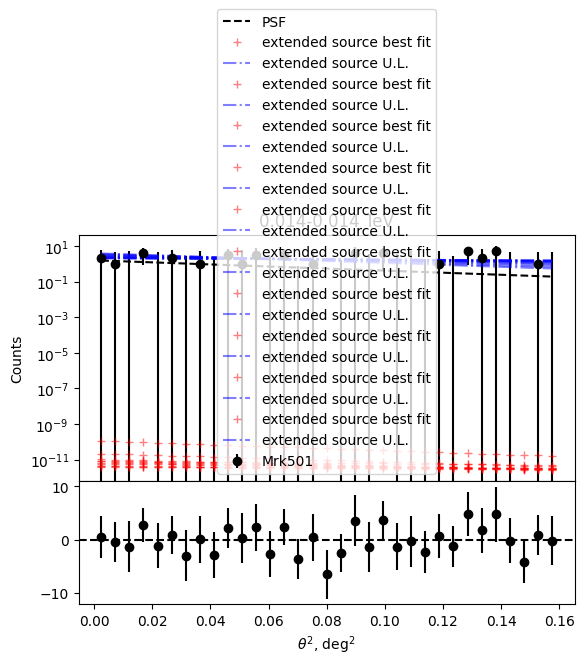

ext_model sum = 66.902992833005
after normalization sum = 1286.9999999999993
Best fit extended plus point gives chi2: 26.74683106515901
ext_model sum = 63.13609820563359
after normalization sum = 1287.0000000000002
Best fit extended plus point gives chi2: 26.446228058725097
ext_model sum = 57.085155689189826
after normalization sum = 1286.9999999999993
Best fit extended plus point gives chi2: 26.44622805872514
ext_model sum = 49.77736295246538
after normalization sum = 1287.0000000000002
Best fit extended plus point gives chi2: 26.446228058725275
ext_model sum = 42.406028465234705
after normalization sum = 1286.9999999999998
Best fit extended plus point gives chi2: 26.446228058724888
ext_model sum = 35.73467536242711
after normalization sum = 1287.0
Best fit extended plus point gives chi2: 26.44622805872497
ext_model sum = 30.04908303799479
after normalization sum = 1287.0
Best fit extended plus point gives chi2: 26.446228058725122
ext_model sum = 25.348200537369795
after normalization

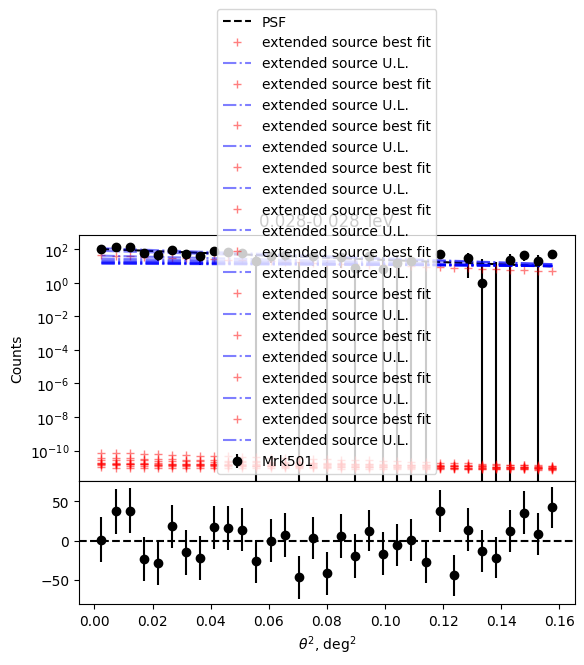

ext_model sum = 45.75822430772634
after normalization sum = 2183.000000000001
Best fit extended plus point gives chi2: 30.825025897496335
ext_model sum = 44.70052794140001
after normalization sum = 2183.0
Best fit extended plus point gives chi2: 30.549843918765422
ext_model sum = 41.35266402266673
after normalization sum = 2183.000000000001
Best fit extended plus point gives chi2: 30.54984391876499
ext_model sum = 36.00969813169194
after normalization sum = 2183.0
Best fit extended plus point gives chi2: 30.54984391876491
ext_model sum = 30.196353258366553
after normalization sum = 2183.000000000001
Best fit extended plus point gives chi2: 30.549843918765433
ext_model sum = 24.94549540496143
after normalization sum = 2183.000000000001
Best fit extended plus point gives chi2: 30.549843918765248
ext_model sum = 20.5841938578381
after normalization sum = 2183.0
Best fit extended plus point gives chi2: 30.54984391876483
ext_model sum = 17.083811038269427
after normalization sum = 2183.0000

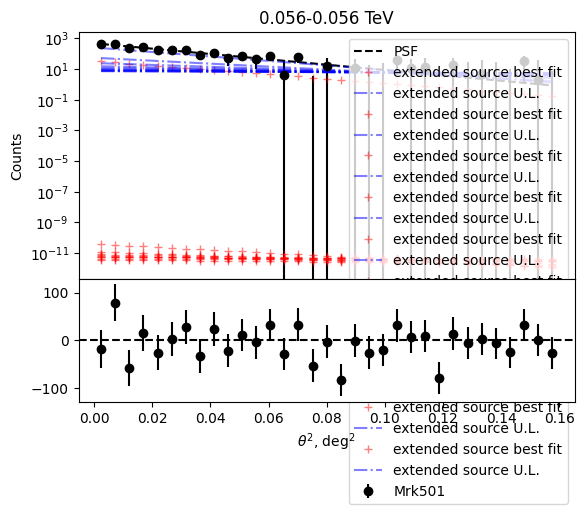

ext_model sum = 36.211896991484146
after normalization sum = 3263.999999999999
Best fit extended plus point gives chi2: 31.14889041935242
ext_model sum = 35.882844744453706
after normalization sum = 3264.0
Best fit extended plus point gives chi2: 31.14889041935239
ext_model sum = 33.72317442456576
after normalization sum = 3263.9999999999995
Best fit extended plus point gives chi2: 31.148890419352345
ext_model sum = 29.50958460945179
after normalization sum = 3264.0
Best fit extended plus point gives chi2: 31.148890419352334
ext_model sum = 24.683114022491605
after normalization sum = 3263.999999999999
Best fit extended plus point gives chi2: 31.148890419352476
ext_model sum = 20.292846660814885
after normalization sum = 3263.9999999999995
Best fit extended plus point gives chi2: 31.148890419352675
ext_model sum = 16.664096167707
after normalization sum = 3264.0000000000005
Best fit extended plus point gives chi2: 31.148890419352753
ext_model sum = 13.772621854090387
after normalizatio

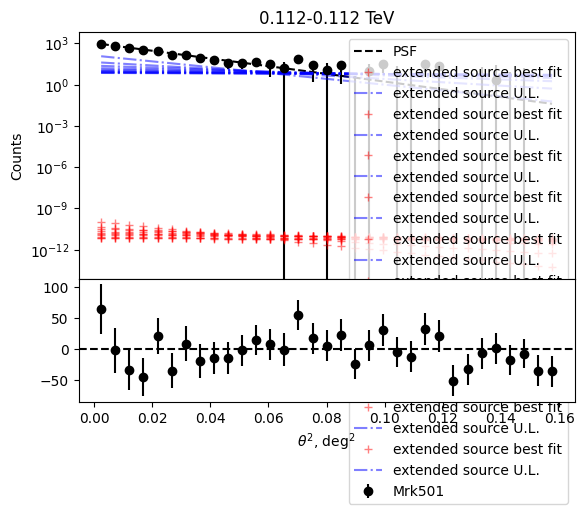

ext_model sum = 23.454508487612117
after normalization sum = 2203.0000000000005
Best fit extended plus point gives chi2: 17.5231149627276
ext_model sum = 23.536905595619984
after normalization sum = 2202.9999999999995
Best fit extended plus point gives chi2: 19.1718290682837
ext_model sum = 22.557400828691083
after normalization sum = 2202.9999999999995
Best fit extended plus point gives chi2: 21.136176324958214
ext_model sum = 19.903227536410025
after normalization sum = 2202.999999999999
Best fit extended plus point gives chi2: 22.149716930345058
ext_model sum = 16.623687872419286
after normalization sum = 2203.0
Best fit extended plus point gives chi2: 22.64977885677442
ext_model sum = 13.604687606136594
after normalization sum = 2202.9999999999995
Best fit extended plus point gives chi2: 22.931940849704013
ext_model sum = 11.11880330656599
after normalization sum = 2202.9999999999995
Best fit extended plus point gives chi2: 23.070815451291466
ext_model sum = 9.151641709912946
after

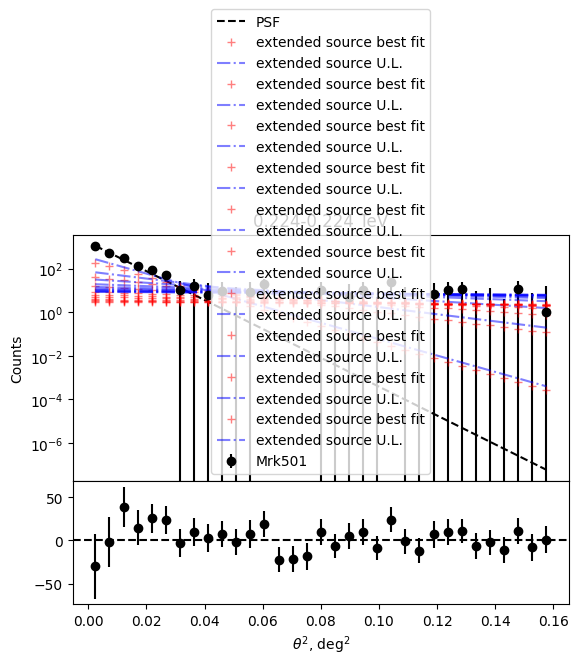

ext_model sum = 19.723754366929338
after normalization sum = 1456.0
Best fit extended plus point gives chi2: 21.218659924292776
ext_model sum = 19.868656780009378
after normalization sum = 1455.9999999999998
Best fit extended plus point gives chi2: 21.218659924292904
ext_model sum = 19.12814683834964
after normalization sum = 1455.9999999999995
Best fit extended plus point gives chi2: 21.218659924293036
ext_model sum = 16.91683208392559
after normalization sum = 1455.9999999999995
Best fit extended plus point gives chi2: 21.218659924293522
ext_model sum = 14.127253346536259
after normalization sum = 1456.0000000000005
Best fit extended plus point gives chi2: 21.2186599242935
ext_model sum = 11.550574036390127
after normalization sum = 1456.0
Best fit extended plus point gives chi2: 21.2186599242933
ext_model sum = 9.430315266476528
after normalization sum = 1455.9999999999995
Best fit extended plus point gives chi2: 21.218659924293327
ext_model sum = 7.754942477740662
after normalizati

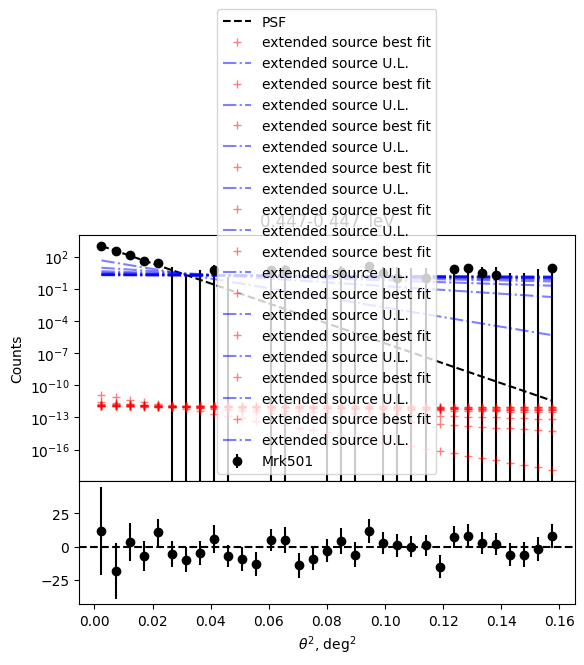

ext_model sum = 15.605812129483983
after normalization sum = 933.0
Best fit extended plus point gives chi2: 20.790682462051773
ext_model sum = 15.804370071965538
after normalization sum = 933.0000000000003
Best fit extended plus point gives chi2: 21.139534101164173
ext_model sum = 15.278625462553531
after normalization sum = 933.0000000000001
Best fit extended plus point gives chi2: 22.001592793788042
ext_model sum = 13.543598535883335
after normalization sum = 933.0
Best fit extended plus point gives chi2: 22.678931894533203
ext_model sum = 11.309372165021658
after normalization sum = 932.9999999999998
Best fit extended plus point gives chi2: 23.142478930458303
ext_model sum = 9.238670191943948
after normalization sum = 933.0000000000003
Best fit extended plus point gives chi2: 23.43793945120874
ext_model sum = 7.53570851506594
after normalization sum = 933.0000000000001
Best fit extended plus point gives chi2: 23.628254658306936
ext_model sum = 6.1918605332761985
after normalization 

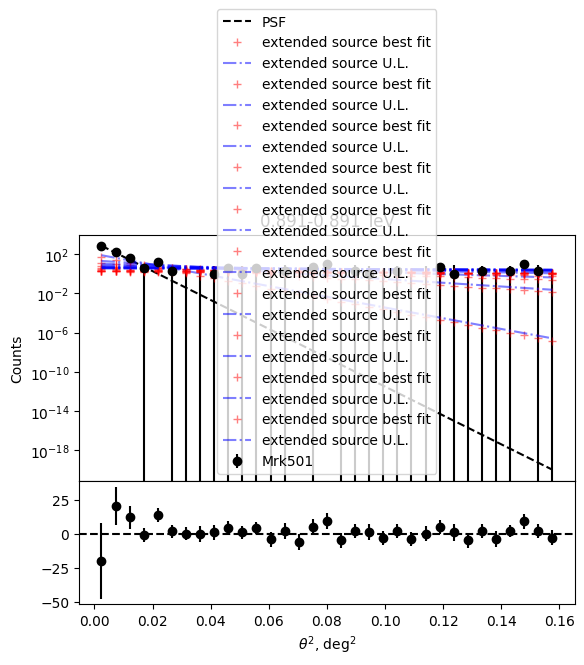

ext_model sum = 14.516698557269288
after normalization sum = 500.00000000000006
Best fit extended plus point gives chi2: 10.559197401124012
ext_model sum = 14.725929704427113
after normalization sum = 500.0
Best fit extended plus point gives chi2: 9.956822565919461
ext_model sum = 14.249507077823175
after normalization sum = 500.00000000000006
Best fit extended plus point gives chi2: 10.73005219558518
ext_model sum = 12.638310472462951
after normalization sum = 499.99999999999994
Best fit extended plus point gives chi2: 11.457129634517804
ext_model sum = 10.553321175728223
after normalization sum = 500.00000000000006
Best fit extended plus point gives chi2: 11.867989132451621
ext_model sum = 8.619367651840841
after normalization sum = 499.9999999999999
Best fit extended plus point gives chi2: 12.08819711354079
ext_model sum = 7.029058478691662
after normalization sum = 499.9999999999999
Best fit extended plus point gives chi2: 12.21158044465565
ext_model sum = 5.774485438087716
after n

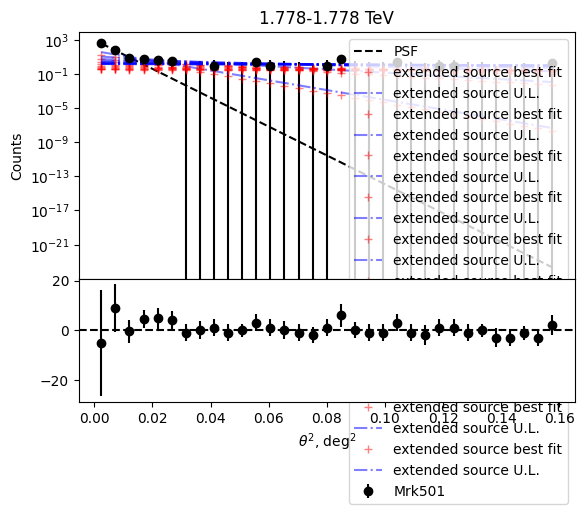

ext_model sum = 13.305962244793383
after normalization sum = 210.0
Best fit extended plus point gives chi2: 6.162037115450676
ext_model sum = 13.524610384483992
after normalization sum = 209.99999999999994
Best fit extended plus point gives chi2: 6.16203711545075
ext_model sum = 13.099794770833665
after normalization sum = 210.00000000000006
Best fit extended plus point gives chi2: 6.16203711545087
ext_model sum = 11.625322258580564
after normalization sum = 210.00000000000009
Best fit extended plus point gives chi2: 6.162037115450936
ext_model sum = 9.707381844568662
after normalization sum = 210.00000000000003
Best fit extended plus point gives chi2: 6.162037115450883
ext_model sum = 7.926860081744541
after normalization sum = 209.99999999999997
Best fit extended plus point gives chi2: 6.162037115450822
ext_model sum = 6.462895130729928
after normalization sum = 210.0
Best fit extended plus point gives chi2: 6.162037115450807
ext_model sum = 5.308351827451264
after normalization sum 

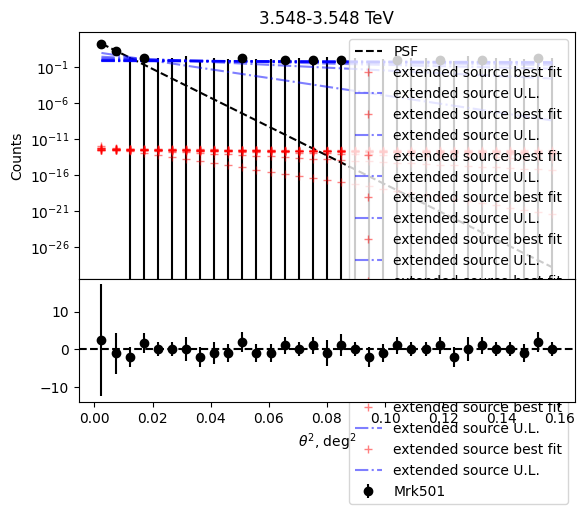

ext_model sum = 12.33753635726106
after normalization sum = 56.999999999999986
Best fit extended plus point gives chi2: 3.254430286727616
ext_model sum = 12.561465524413968
after normalization sum = 57.000000000000036
Best fit extended plus point gives chi2: 3.2544302867276627
ext_model sum = 12.17566844160229
after normalization sum = 57.00000000000003
Best fit extended plus point gives chi2: 3.2544302867276524
ext_model sum = 10.809918355262838
after normalization sum = 56.99999999999998
Best fit extended plus point gives chi2: 3.2544302867277124
ext_model sum = 9.026475671881016
after normalization sum = 57.00000000000001
Best fit extended plus point gives chi2: 3.254430286727709
ext_model sum = 7.369751769692315
after normalization sum = 57.00000000000001
Best fit extended plus point gives chi2: 3.2544302867277195
ext_model sum = 6.00769338001269
after normalization sum = 56.999999999999986
Best fit extended plus point gives chi2: 3.254430286727655
ext_model sum = 4.933764579660027

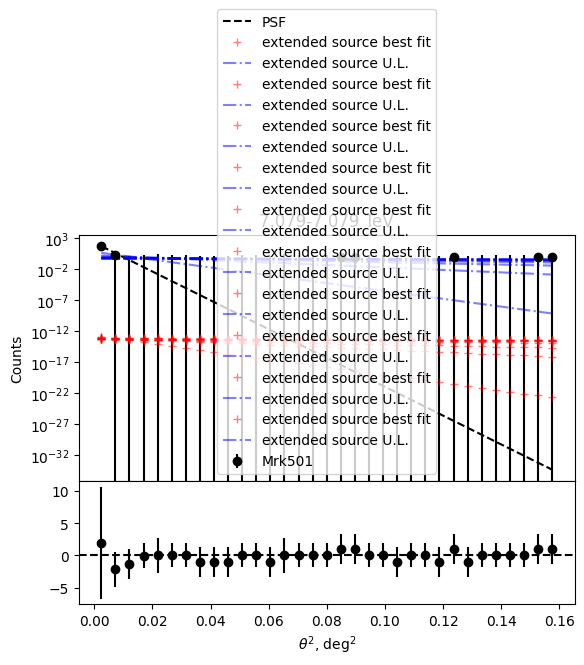

In [11]:
flux_ratios_40deg = calculate_UL(cts_40deg, cts_err_40deg, psf_hbu_40deg)
flux_ratios_20deg = calculate_UL(cts_20deg, cts_err_20deg, psf_hbu_20deg)

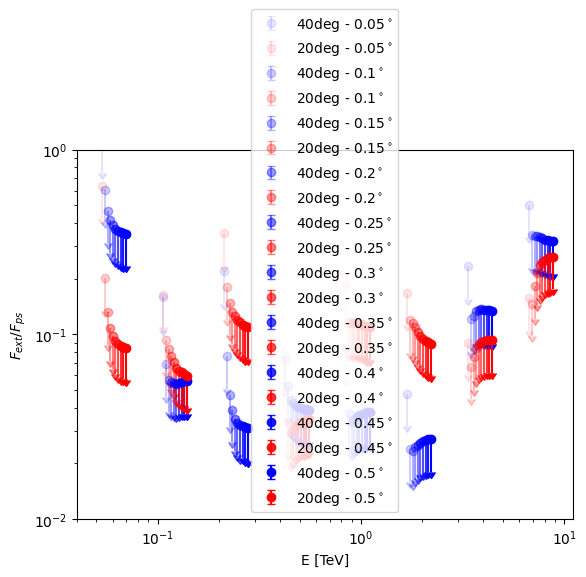

In [12]:
for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01, 1)
plt.legend()

In [13]:
def calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    th2_extended = np.concatenate([th2, th2])
    
    for i, ((ct_40deg, ct_err_40deg), (ct_20deg, ct_err_20deg)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
        ct = np.concatenate([ct_40deg, ct_20deg])
        ct_err = np.concatenate([ct_err_40deg, ct_err_20deg])
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1_40deg, sigma_2_40deg, sigma_3_40deg, scale_40deg, ampl_2_40deg, ampl_3_40deg = psf_hbu_40deg.data[psf_index][0]
        sigma_1_20deg, sigma_2_20deg, sigma_3_20deg, scale_20deg, ampl_2_20deg, ampl_3_20deg = psf_hbu_20deg.data[psf_index][0]
        
        # Normalization of the PSF model to fit best the blazar
        def psf_model_40deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_40deg**2))
            gauss2 = ampl_2_40deg * np.exp(-th2 / (2 * sigma_2_40deg**2))
            gauss3 = ampl_3_40deg * np.exp(-th2 / (2 * sigma_3_40deg**2))
            return (gauss1 + gauss2 + gauss3)
         
        def psf_model_20deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_20deg**2))
            gauss2 = ampl_2_20deg * np.exp(-th2 / (2 * sigma_2_20deg**2))
            gauss3 = ampl_3_20deg * np.exp(-th2 / (2 * sigma_3_20deg**2))
            return (gauss1 + gauss2 + gauss3)

        psf_component_40deg = psf_model_40deg(th2)
        psf_component_20deg = psf_model_20deg(th2)

        psf_component_40deg = sum(ct_40deg) * psf_component_40deg / sum(psf_component_40deg)
        psf_component_20deg = sum(ct_20deg) * psf_component_20deg / sum(psf_component_20deg)

        psf_component_err_40deg = np.zeros_like(psf_component_40deg)
        psf_component_err_20deg = np.zeros_like(psf_component_20deg)

        chi2_noext_40deg = np.sum(((ct_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))
        chi2_noext_20deg = np.sum(((ct_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))
    
        step = 1.01
        
        chi2_noext_best_40deg = 1e10
        adjust_40deg = 1
        while chi2_noext_40deg < chi2_noext_best_40deg:
            chi2_noext_best_40deg = chi2_noext_40deg
            
            chisq0 = sum((ct_40deg - step*adjust_40deg*psf_component_40deg)**2 / 
                         (ct_err_40deg**2 + (step*adjust_40deg*psf_component_err_40deg)**2))
            chisq1 = sum((ct_40deg - adjust_40deg*psf_component_40deg/step)**2 / 
                         (ct_err_40deg**2 + (adjust_40deg*psf_component_err_40deg/step)**2))
            chisq_vec = np.array([chisq0, chisq1])
            chi2_noext_40deg = min(chisq_vec)
            ind = np.argmin(chisq_vec)
            
            if chi2_noext_40deg < chi2_noext_best_40deg:
                if ind == 0:
                    adjust_40deg *= step
                elif ind == 1:
                    adjust_40deg /= step

        chi2_noext_best_20deg = 1e10
        adjust_20deg = 1
        while chi2_noext_20deg < chi2_noext_best_20deg:
            chi2_noext_best_20deg = chi2_noext_20deg
            
            chisq0 = sum((ct_20deg - step*adjust_20deg*psf_component_20deg)**2 / 
                         (ct_err_20deg**2 + (step*adjust_20deg*psf_component_err_20deg)**2))
            chisq1 = sum((ct_20deg - adjust_20deg*psf_component_20deg/step)**2 / 
                         (ct_err_20deg**2 + (adjust_20deg*psf_component_err_20deg/step)**2))
            chisq_vec = np.array([chisq0, chisq1])
            chi2_noext_20deg = min(chisq_vec)
            ind = np.argmin(chisq_vec)
            
            if chi2_noext_20deg < chi2_noext_best_20deg:
                if ind == 0:
                    adjust_20deg *= step
                elif ind == 1:
                    adjust_20deg /= step

        psf_component_40deg *= adjust_40deg
        psf_component_err_40deg *= adjust_40deg
        psf_component_20deg *= adjust_20deg
        psf_component_err_20deg *= adjust_20deg

        psf_component_40deg_noext_best = psf_component_40deg
        psf_component_20deg_noext_best = psf_component_20deg
        psf_component_err_40deg_noext_best = psf_component_err_40deg
        psf_component_err_20deg_noext_best = psf_component_err_20deg
        
        chi2_noext = np.sum(((ct_40deg - psf_component_40deg)**2 / (ct_err_40deg**2))) + np.sum(((ct_20deg - psf_component_20deg)**2 / (ct_err_20deg**2))) 

        fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='row', gridspec_kw={'height_ratios': [2, 1], 'width_ratios': [1, 1]})
        fig.subplots_adjust(hspace=0, wspace=0.3)
        
        axs[0,0].errorbar(th2,ct_40deg,ct_err_40deg,linestyle='none',marker='o',label=name,color='black')
        axs[0,0].plot(th2,psf_component_40deg,color='black',linestyle='dashed',label='PSF')
        axs[0,0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1,0].errorbar(th2,ct_40deg - psf_component_40deg,np.sqrt(ct_err_40deg**2+psf_component_err_40deg**2),marker='o',linestyle='none',color='black')
        axs[1,0].axhline(0,color='black',linestyle='dashed')
        axs[0,1].errorbar(th2,ct_20deg,ct_err_20deg,linestyle='none',marker='o',label=name,color='black')
        axs[0,1].plot(th2,psf_component_20deg,color='black',linestyle='dashed',label='PSF')
        axs[0,1].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1,1].errorbar(th2,ct_20deg - psf_component_20deg,np.sqrt(ct_err_20deg**2+psf_component_err_20deg**2),marker='o',linestyle='none',color='black')
        axs[1,1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            psf_component_40deg = psf_component_40deg_noext_best     
            psf_component_20deg = psf_component_20deg_noext_best     
            psf_component_err_40deg = psf_component_err_40deg_noext_best 
            psf_component_err_20deg = psf_component_err_20deg_noext_best 
            
            def ext_model_40deg(th2):
                sigma1_conv = np.sqrt(sigma_1_40deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_40deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_40deg**2 + sigma_ext**2)
                c1 = sigma_1_40deg/(sigma_1_40deg**2 + sigma_ext**2)
                c2 = ampl_2_40deg*sigma_2_40deg/(sigma_2_40deg**2 + sigma_ext**2)
                c3 = ampl_3_40deg*sigma_3_40deg/(sigma_3_40deg**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return (gauss1_conv + gauss2_conv + gauss3_conv)

            def ext_model_20deg(th2):
                sigma1_conv = np.sqrt(sigma_1_20deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_20deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_20deg**2 + sigma_ext**2)
                c1 = sigma_1_20deg/(sigma_1_20deg**2 + sigma_ext**2)
                c2 = ampl_2_20deg*sigma_2_20deg/(sigma_2_20deg**2 + sigma_ext**2)
                c3 = ampl_3_20deg*sigma_3_20deg/(sigma_3_20deg**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return (gauss1_conv + gauss2_conv + gauss3_conv)

            ct_ext_40deg = ext_model_40deg(th2)
            ct_ext_20deg = ext_model_20deg(th2)
            print(f"ext_model_20deg sum = {sum(ct_ext_20deg)}")

            ct_ext_40deg = sum(ct_40deg) * ct_ext_40deg / sum(ct_ext_40deg)
            ct_ext_20deg = sum(ct_20deg) * ct_ext_20deg / sum(ct_ext_20deg)
            print(f"after normalization sum = {sum(ct_ext_20deg)}")

            chi2_ext_40deg = np.sum(((ct_40deg - ct_ext_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))
            chi2_ext_20deg = np.sum(((ct_20deg - ct_ext_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))

            step = 1.01
            
            chi2_ext_best_40deg = 1e10
            adjust_ext_40deg = 1
            adjust_point_40deg = 1
            
            while chi2_ext_40deg < chi2_ext_best_40deg:
                chi2_ext_best_40deg = chi2_ext_40deg
                
                chisq0 = sum((ct_40deg - step*adjust_point_40deg*psf_component_40deg - adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + (step*adjust_point_40deg*psf_component_err_40deg)**2))
                chisq1 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg/step - adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + (adjust_point_40deg*psf_component_err_40deg/step)**2))
                chisq2 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg - step*adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + adjust_point_40deg*psf_component_err_40deg**2))
                chisq3 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg - adjust_ext_40deg*ct_ext_40deg/step)**2 / 
                             (ct_err_40deg**2 + adjust_point_40deg*psf_component_err_40deg**2))
                
                chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                chi2_ext_40deg = min(chisq_vec)
                ind = np.argmin(chisq_vec)
                
                if chi2_ext_40deg < chi2_ext_best_40deg:
                    if ind == 0:
                        adjust_point_40deg *= step
                    if ind == 1:
                        adjust_point_40deg /= step
                    if ind == 2:
                        adjust_ext_40deg *= step
                    if ind == 3:
                        adjust_ext_40deg /= step

            chi2_ext_best_20deg = 1e10
            adjust_ext_20deg = 1
            adjust_point_20deg = 1
            
            while chi2_ext_20deg < chi2_ext_best_20deg:
                chi2_ext_best_20deg = chi2_ext_20deg
                
                chisq0 = sum((ct_20deg - step*adjust_point_20deg*psf_component_20deg - adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + (step*adjust_point_20deg*psf_component_err_20deg)**2))
                chisq1 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg/step - adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + (adjust_point_20deg*psf_component_err_20deg/step)**2))
                chisq2 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg - step*adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + adjust_point_20deg*psf_component_err_20deg**2))
                chisq3 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg - adjust_ext_20deg*ct_ext_20deg/step)**2 / 
                             (ct_err_20deg**2 + adjust_point_20deg*psf_component_err_20deg**2))
                
                chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                chi2_ext_20deg = min(chisq_vec)
                ind = np.argmin(chisq_vec)
                
                if chi2_ext_20deg < chi2_ext_best_20deg:
                    if ind == 0:
                        adjust_point_20deg *= step
                    if ind == 1:
                        adjust_point_20deg /= step
                    if ind == 2:
                        adjust_ext_20deg *= step
                    if ind == 3:
                        adjust_ext_20deg /= step
            
            ct_ext_40deg *= adjust_ext_40deg
            psf_component_40deg *= adjust_point_40deg
            psf_component_err_40deg *= adjust_point_40deg

            ct_ext_20deg *= adjust_ext_20deg
            psf_component_20deg *= adjust_point_20deg
            psf_component_err_20deg *= adjust_point_20deg

            # From now on i keep the calues concatenated. I'm renomalizing the extended component equally for the two zenith angles.
            # This might be wrong, I still have to think about it.
            ct_ext = np.concatenate([ct_ext_40deg, ct_ext_20deg])
            psf_component = np.concatenate([psf_component_40deg, psf_component_20deg])
            psf_component_err = np.concatenate([psf_component_err_40deg, psf_component_err_20deg])
            cts_tot_best = np.sum(ct_ext + psf_component)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")
            axs[0,0].plot(th2,ct_ext[:len(th2)],color='red',alpha=0.5,marker='+', linestyle="none",label='extended source best fit')
            axs[0,1].plot(th2,ct_ext[len(th2):],color='red',alpha=0.5,marker='+', linestyle="none",label='extended source best fit')

            # Upper limits
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point_20deg_ul = 1
            adjust_point_40deg_ul = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext

                    chisq0 = sum((ct - ct_ext - np.concatenate([step*adjust_point_40deg_ul*psf_component_40deg, 
                                                                 adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)

                    chisq1 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg/step, 
                                                                 adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq2 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg, 
                                                                 step*adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq3 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg, 
                                                                 adjust_point_20deg_ul*psf_component_20deg/step]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                    chi2_ext = min(chisq_vec)
                    ind = np.argmin(chisq_vec)
                    
                    if chi2_ext < chi2_ext_best_fixed_ext:
                        if ind == 0:
                            adjust_point_40deg_ul *= step
                        elif ind == 1:
                            adjust_point_40deg_ul /= step
                        elif ind == 2:
                            adjust_point_20deg_ul *= step
                        elif ind == 3:
                            adjust_point_20deg_ul /= step

            flux_ratio = np.sum(ct_ext)/cts_tot_best
            flux_ratios[k][i] = flux_ratio
            axs[0,0].plot(th2,ct_ext[:len(th2)],color='blue',alpha=0.5,marker='+', linestyle="none",label='extended source U.L.')
            axs[0,1].plot(th2,ct_ext[len(th2):],color='blue',alpha=0.5,marker='+', linestyle="none",label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0,0].set_ylabel('Counts')
        axs[0,0].legend()
        axs[0,0].set_yscale('log')
        axs[0,1].set_ylabel('Counts')
        axs[0,1].legend()
        axs[0,1].set_yscale('log')
        plt.show()
    return flux_ratios

ext_model_20deg sum = 69.0109101794082
after normalization sum = 17.0
Best fit extended plus point gives chi2: 13.905996097519083
ext_model_20deg sum = 65.00491832974576
after normalization sum = 16.999999999999996
Best fit extended plus point gives chi2: 13.885647897765612
ext_model_20deg sum = 58.78006192680647
after normalization sum = 17.000000000000004
Best fit extended plus point gives chi2: 13.86109897121527
ext_model_20deg sum = 51.385941954768086
after normalization sum = 17.0
Best fit extended plus point gives chi2: 13.841141986563612
ext_model_20deg sum = 43.94887925912299
after normalization sum = 16.999999999999993
Best fit extended plus point gives chi2: 13.827758584730999
ext_model_20deg sum = 37.19139482839307
after normalization sum = 16.999999999999996
Best fit extended plus point gives chi2: 13.819281801279923
ext_model_20deg sum = 31.3963640838325
after normalization sum = 17.000000000000004
Best fit extended plus point gives chi2: 13.813870347927178
ext_model_20deg

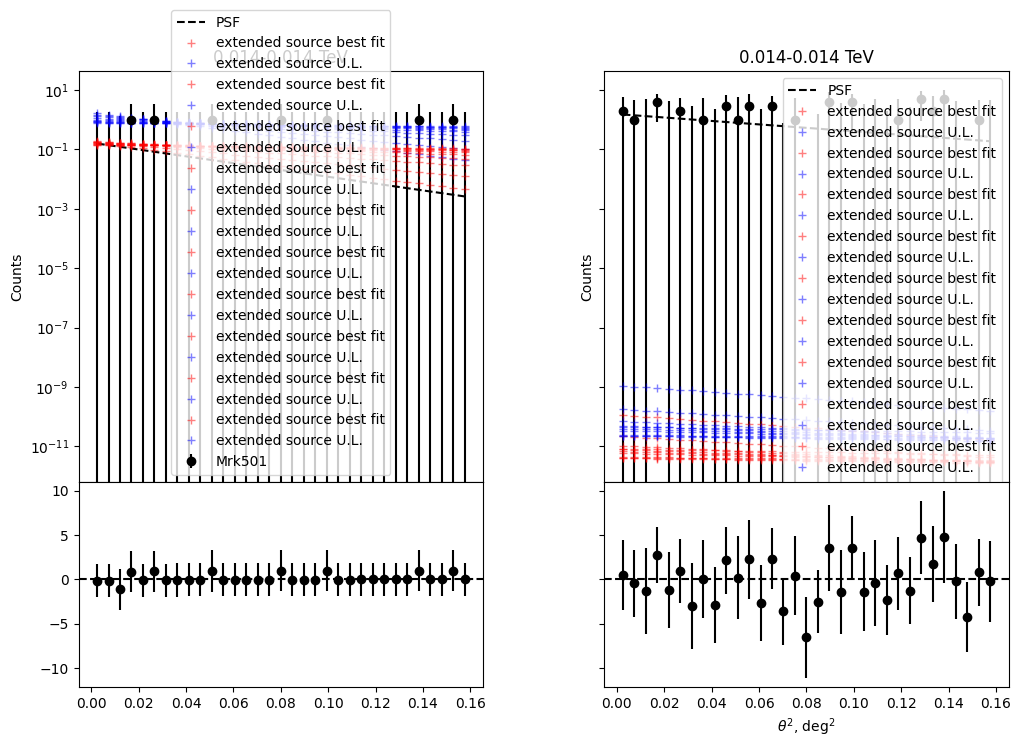

ext_model_20deg sum = 66.902992833005
after normalization sum = 1286.9999999999993
Best fit extended plus point gives chi2: 61.099316194849024
ext_model_20deg sum = 63.13609820563359
after normalization sum = 1287.0000000000002
Best fit extended plus point gives chi2: 60.030680803565915
ext_model_20deg sum = 57.085155689189826
after normalization sum = 1286.9999999999993
Best fit extended plus point gives chi2: 60.19545643209306
ext_model_20deg sum = 49.77736295246538
after normalization sum = 1287.0000000000002
Best fit extended plus point gives chi2: 60.39670698225565
ext_model_20deg sum = 42.406028465234705
after normalization sum = 1286.9999999999998
Best fit extended plus point gives chi2: 60.5502774534089
ext_model_20deg sum = 35.73467536242711
after normalization sum = 1287.0
Best fit extended plus point gives chi2: 60.65883612681689
ext_model_20deg sum = 30.04908303799479
after normalization sum = 1287.0
Best fit extended plus point gives chi2: 60.73571008292681
ext_model_20deg

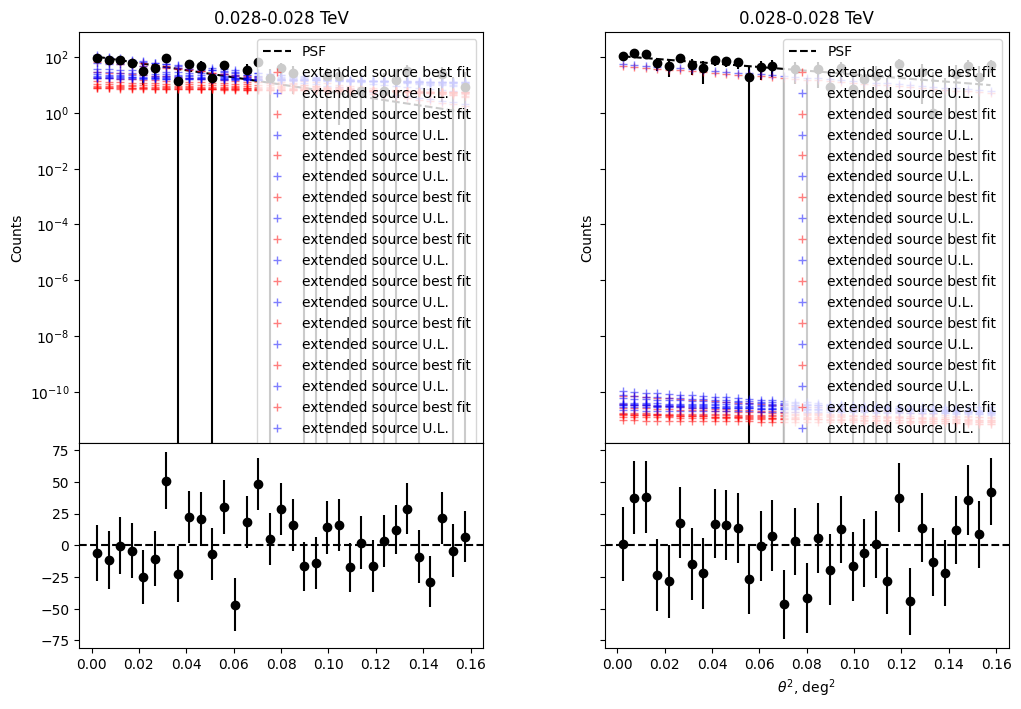

ext_model_20deg sum = 45.75822430772634
after normalization sum = 2183.000000000001
Best fit extended plus point gives chi2: 55.478687740571786
ext_model_20deg sum = 44.70052794140001
after normalization sum = 2183.0
Best fit extended plus point gives chi2: 53.83028253501607
ext_model_20deg sum = 41.35266402266673
after normalization sum = 2183.000000000001
Best fit extended plus point gives chi2: 52.424365369363784
ext_model_20deg sum = 36.00969813169194
after normalization sum = 2183.0
Best fit extended plus point gives chi2: 51.61989072274962
ext_model_20deg sum = 30.196353258366553
after normalization sum = 2183.000000000001
Best fit extended plus point gives chi2: 51.204415315044876
ext_model_20deg sum = 24.94549540496143
after normalization sum = 2183.000000000001
Best fit extended plus point gives chi2: 51.003274770231684
ext_model_20deg sum = 20.5841938578381
after normalization sum = 2183.0
Best fit extended plus point gives chi2: 50.88783761750571
ext_model_20deg sum = 17.083

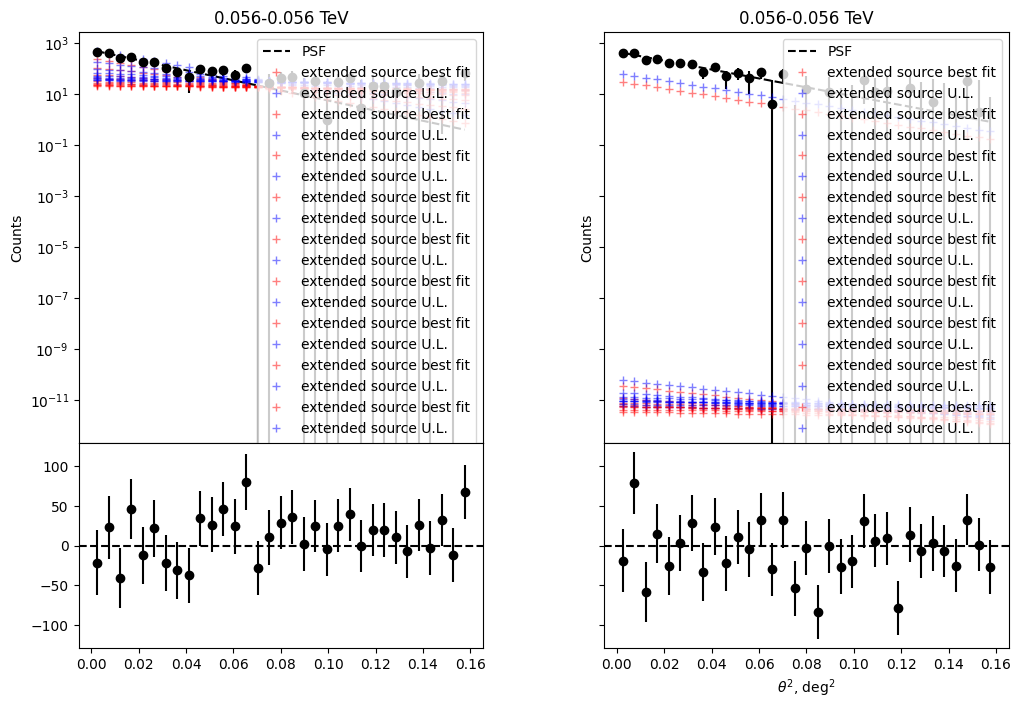

ext_model_20deg sum = 36.211896991484146
after normalization sum = 3263.999999999999
Best fit extended plus point gives chi2: 67.28023499965957
ext_model_20deg sum = 35.882844744453706
after normalization sum = 3264.0
Best fit extended plus point gives chi2: 67.28023499965997
ext_model_20deg sum = 33.72317442456576
after normalization sum = 3263.9999999999995
Best fit extended plus point gives chi2: 67.28023499965997
ext_model_20deg sum = 29.50958460945179
after normalization sum = 3264.0
Best fit extended plus point gives chi2: 67.28023499966015
ext_model_20deg sum = 24.683114022491605
after normalization sum = 3263.999999999999
Best fit extended plus point gives chi2: 67.28023499965995
ext_model_20deg sum = 20.292846660814885
after normalization sum = 3263.9999999999995
Best fit extended plus point gives chi2: 67.28023499966045
ext_model_20deg sum = 16.664096167707
after normalization sum = 3264.0000000000005
Best fit extended plus point gives chi2: 67.2802349996604
ext_model_20deg s

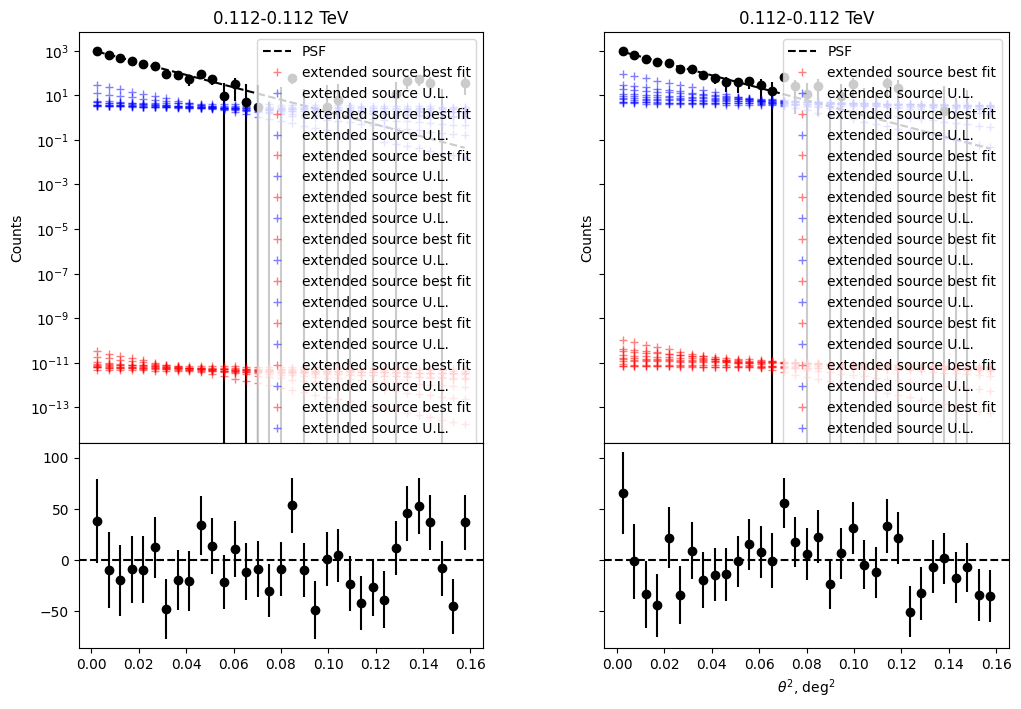

ext_model_20deg sum = 23.454508487612117
after normalization sum = 2203.0000000000005
Best fit extended plus point gives chi2: 49.11848875801652
ext_model_20deg sum = 23.536905595619984
after normalization sum = 2202.9999999999995
Best fit extended plus point gives chi2: 50.74194361099593
ext_model_20deg sum = 22.557400828691083
after normalization sum = 2202.9999999999995
Best fit extended plus point gives chi2: 52.70629086767067
ext_model_20deg sum = 19.903227536410025
after normalization sum = 2202.999999999999
Best fit extended plus point gives chi2: 53.7198314730574
ext_model_20deg sum = 16.623687872419286
after normalization sum = 2203.0
Best fit extended plus point gives chi2: 54.21989339948687
ext_model_20deg sum = 13.604687606136594
after normalization sum = 2202.9999999999995
Best fit extended plus point gives chi2: 54.502055392417
ext_model_20deg sum = 11.11880330656599
after normalization sum = 2202.9999999999995
Best fit extended plus point gives chi2: 54.64092999400457
ex

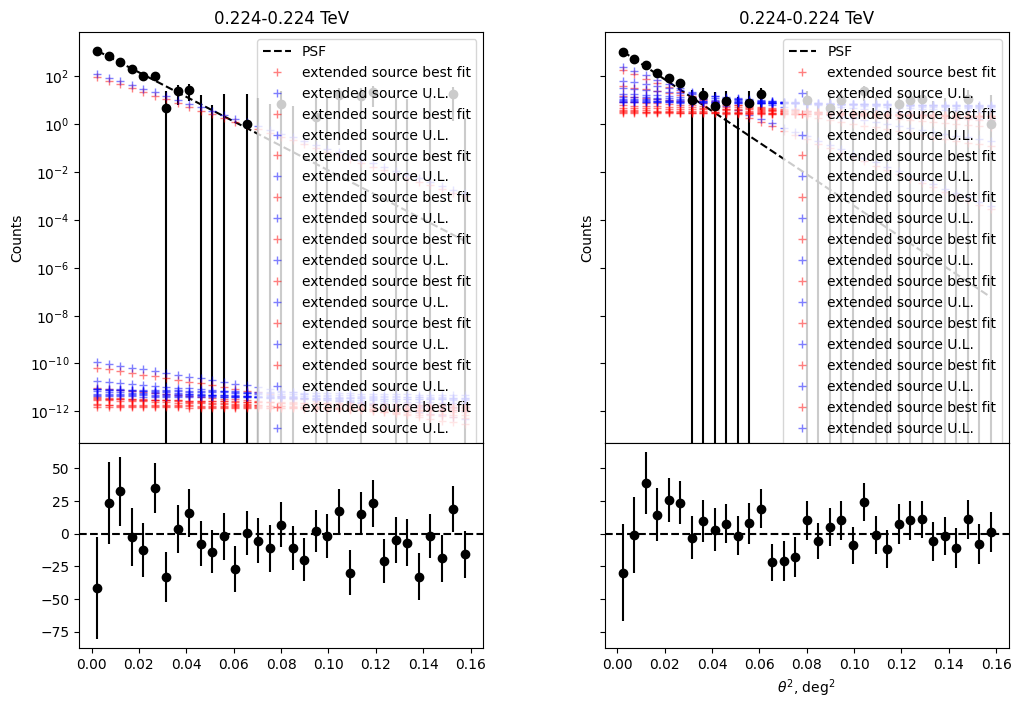

ext_model_20deg sum = 19.723754366929338
after normalization sum = 1456.0
Best fit extended plus point gives chi2: 67.19452391797577
ext_model_20deg sum = 19.868656780009378
after normalization sum = 1455.9999999999998
Best fit extended plus point gives chi2: 67.19452391797732
ext_model_20deg sum = 19.12814683834964
after normalization sum = 1455.9999999999995
Best fit extended plus point gives chi2: 67.19452391797812
ext_model_20deg sum = 16.91683208392559
after normalization sum = 1455.9999999999995
Best fit extended plus point gives chi2: 67.19452391797786
ext_model_20deg sum = 14.127253346536259
after normalization sum = 1456.0000000000005
Best fit extended plus point gives chi2: 67.1945239179777
ext_model_20deg sum = 11.550574036390127
after normalization sum = 1456.0
Best fit extended plus point gives chi2: 67.19452391797681
ext_model_20deg sum = 9.430315266476528
after normalization sum = 1455.9999999999995
Best fit extended plus point gives chi2: 67.19452391797702
ext_model_20d

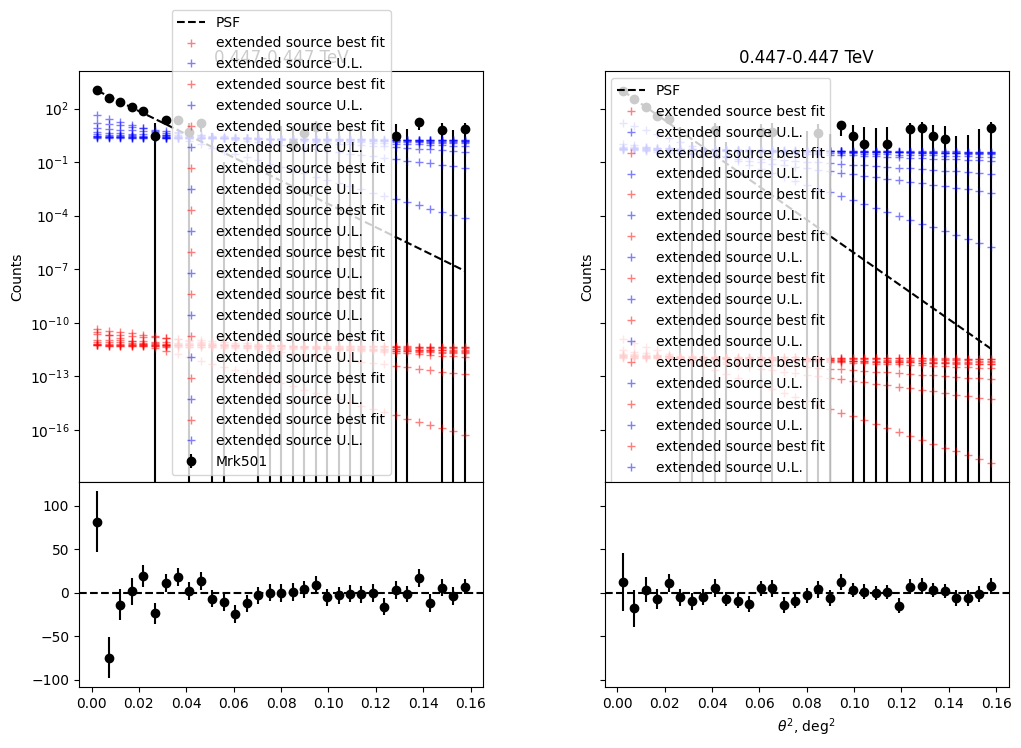

ext_model_20deg sum = 15.605812129483983
after normalization sum = 933.0
Best fit extended plus point gives chi2: 42.11431768638783
ext_model_20deg sum = 15.804370071965538
after normalization sum = 933.0000000000003
Best fit extended plus point gives chi2: 42.46316932550039
ext_model_20deg sum = 15.278625462553531
after normalization sum = 933.0000000000001
Best fit extended plus point gives chi2: 43.325228018124434
ext_model_20deg sum = 13.543598535883335
after normalization sum = 933.0
Best fit extended plus point gives chi2: 44.00256711886957
ext_model_20deg sum = 11.309372165021658
after normalization sum = 932.9999999999998
Best fit extended plus point gives chi2: 44.46611415479505
ext_model_20deg sum = 9.238670191943948
after normalization sum = 933.0000000000003
Best fit extended plus point gives chi2: 44.761574675546036
ext_model_20deg sum = 7.53570851506594
after normalization sum = 933.0000000000001
Best fit extended plus point gives chi2: 44.95188988264348
ext_model_20deg s

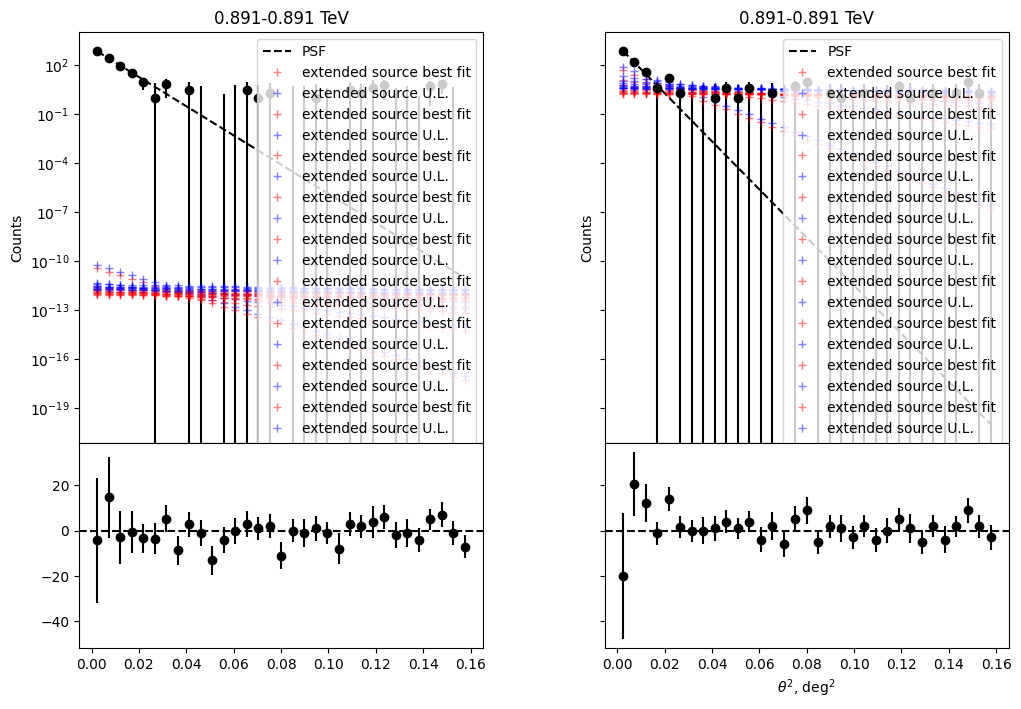

ext_model_20deg sum = 14.516698557269288
after normalization sum = 500.00000000000006
Best fit extended plus point gives chi2: 31.87527813970456
ext_model_20deg sum = 14.725929704427113
after normalization sum = 500.0
Best fit extended plus point gives chi2: 31.272903304499913
ext_model_20deg sum = 14.249507077823175
after normalization sum = 500.00000000000006
Best fit extended plus point gives chi2: 32.046132934165804
ext_model_20deg sum = 12.638310472462951
after normalization sum = 499.99999999999994
Best fit extended plus point gives chi2: 32.773210373098415
ext_model_20deg sum = 10.553321175728223
after normalization sum = 500.00000000000006
Best fit extended plus point gives chi2: 33.18406987103281
ext_model_20deg sum = 8.619367651840841
after normalization sum = 499.9999999999999
Best fit extended plus point gives chi2: 33.40427785212205
ext_model_20deg sum = 7.029058478691662
after normalization sum = 499.9999999999999
Best fit extended plus point gives chi2: 33.52766118323646

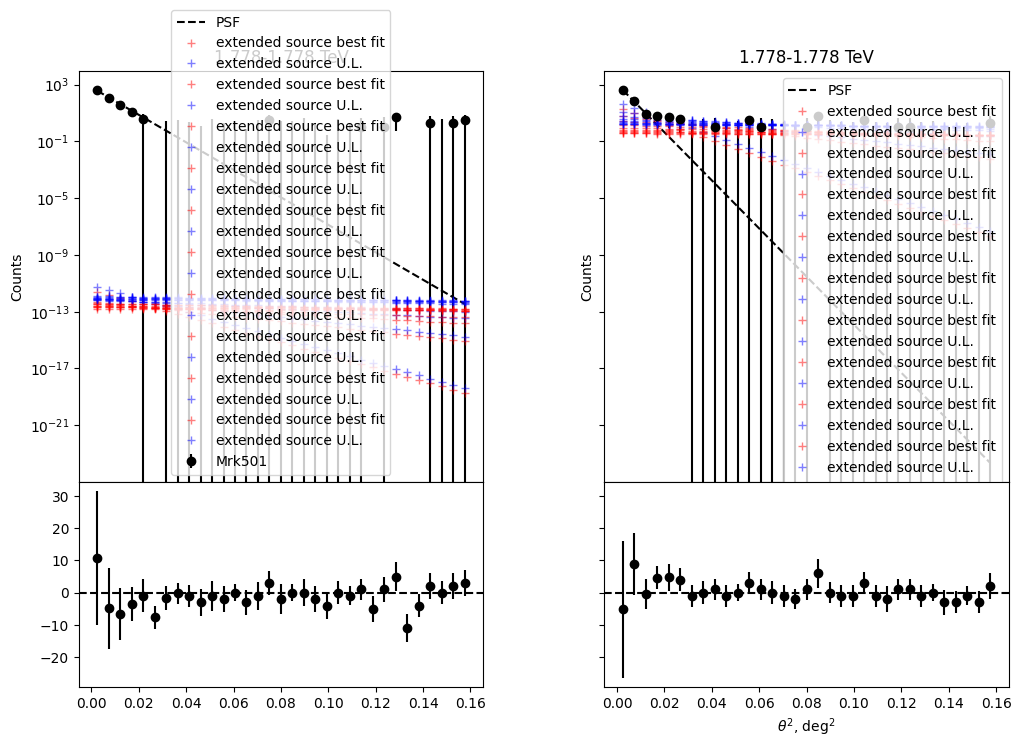

ext_model_20deg sum = 13.305962244793383
after normalization sum = 210.0
Best fit extended plus point gives chi2: 17.576691378072955
ext_model_20deg sum = 13.524610384483992
after normalization sum = 209.99999999999994
Best fit extended plus point gives chi2: 17.629189474989033
ext_model_20deg sum = 13.099794770833665
after normalization sum = 210.00000000000006
Best fit extended plus point gives chi2: 17.606144082832813
ext_model_20deg sum = 11.625322258580564
after normalization sum = 210.00000000000009
Best fit extended plus point gives chi2: 17.57299503356134
ext_model_20deg sum = 9.707381844568662
after normalization sum = 210.00000000000003
Best fit extended plus point gives chi2: 17.55193615607569
ext_model_20deg sum = 7.926860081744541
after normalization sum = 209.99999999999997
Best fit extended plus point gives chi2: 17.54067446182158
ext_model_20deg sum = 6.462895130729928
after normalization sum = 210.0
Best fit extended plus point gives chi2: 17.534536068293527
ext_model_

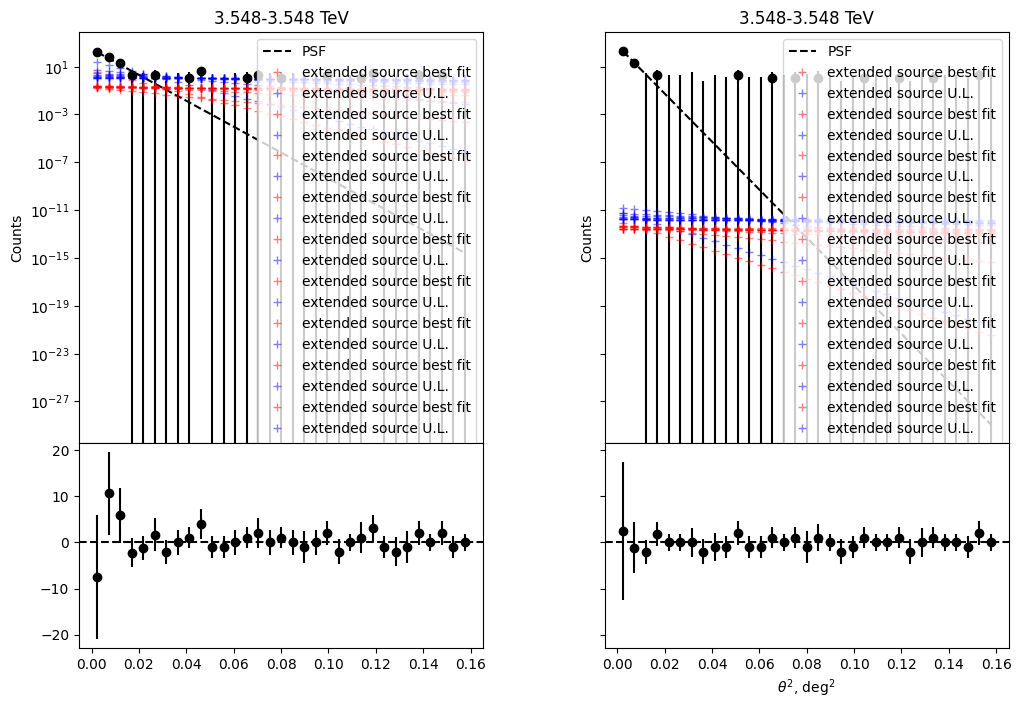

ext_model_20deg sum = 12.33753635726106
after normalization sum = 56.999999999999986
Best fit extended plus point gives chi2: 7.988938774888127
ext_model_20deg sum = 12.561465524413968
after normalization sum = 57.000000000000036
Best fit extended plus point gives chi2: 7.813205260461643
ext_model_20deg sum = 12.17566844160229
after normalization sum = 57.00000000000003
Best fit extended plus point gives chi2: 7.809657267293696
ext_model_20deg sum = 10.809918355262838
after normalization sum = 56.99999999999998
Best fit extended plus point gives chi2: 7.881658051474685
ext_model_20deg sum = 9.026475671881016
after normalization sum = 57.00000000000001
Best fit extended plus point gives chi2: 7.943196808205745
ext_model_20deg sum = 7.369751769692315
after normalization sum = 57.00000000000001
Best fit extended plus point gives chi2: 7.98342607455308
ext_model_20deg sum = 6.00769338001269
after normalization sum = 56.999999999999986
Best fit extended plus point gives chi2: 8.008733008739

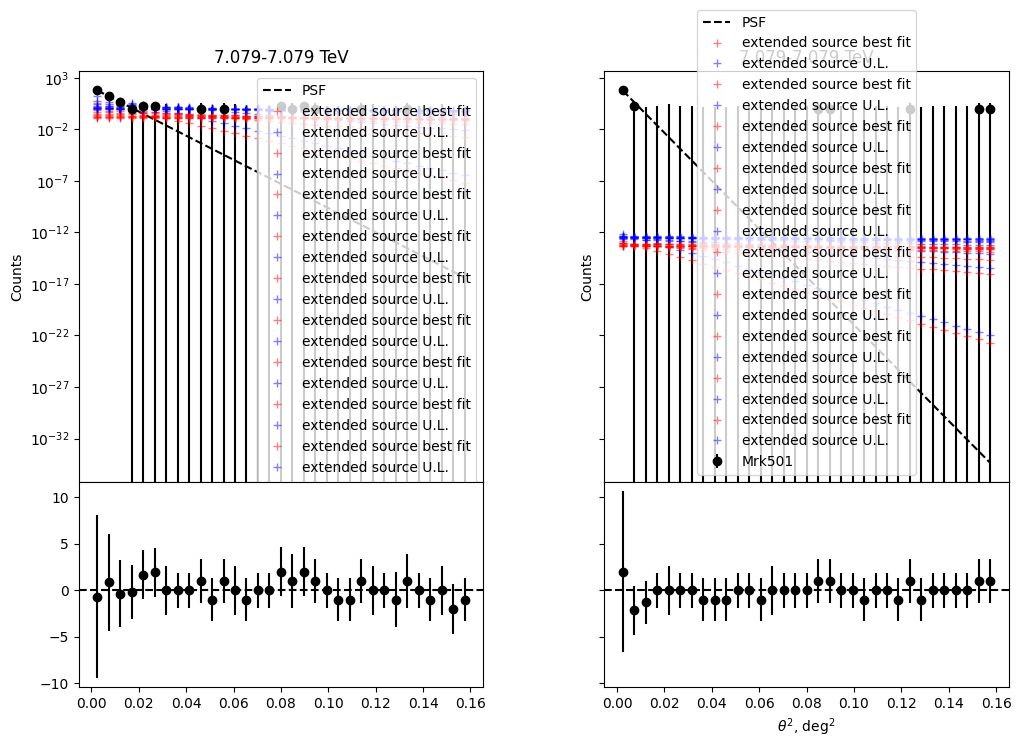

In [14]:
flux_ratios = calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg)

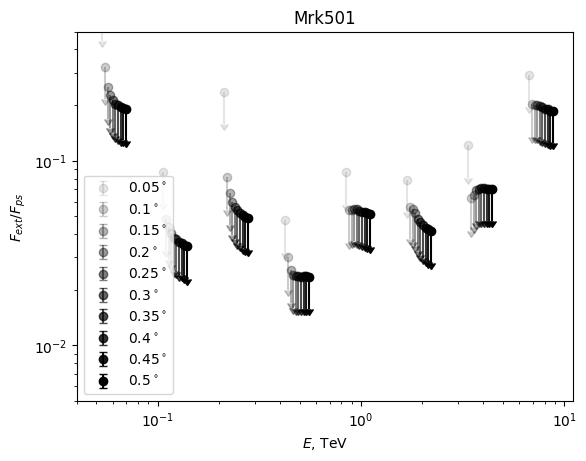

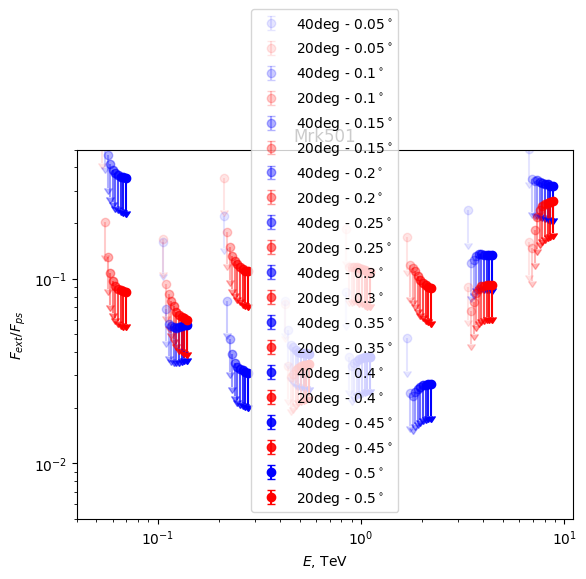

In [15]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,np.abs(flux_ratio/3), alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel(r"$E$, TeV")
plt.xlim(0.04,11)
plt.ylim(0.005, 0.5)
plt.legend()
plt.title(f"{name}")
plt.savefig(f'./images/UL_{name}_DC.png', dpi=600, bbox_inches='tight')
plt.show()

for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel(r"$E$, TeV")
plt.xlim(0.04,11)
plt.ylim(0.005, 0.5)
plt.legend()
plt.title(f"{name}")
plt.savefig(f'./images/UL_{name}_DC_2angles.png', dpi=600, bbox_inches='tight')

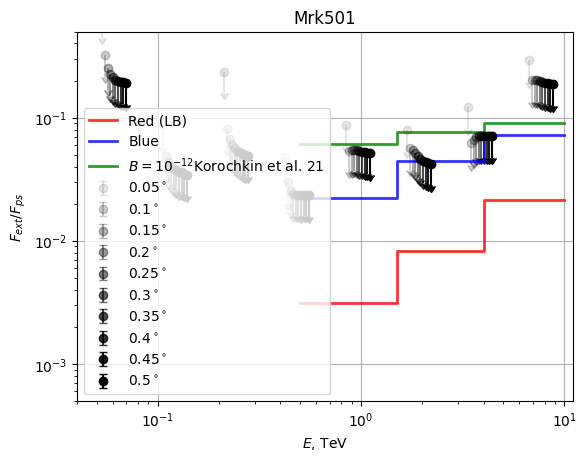

In [16]:
koro_energies = [0.5, 1.5, 1.5, 4, 4, 10]
red_ratios = [0.0031, 0.0031, 0.0083,0.0083, 0.0215,0.0215]
blue_ratios = [0.0223, 0.0223, 0.0448, 0.0448, 0.0724, 0.0724]
green_ratios = [0.0607, 0.0607, 0.0771, 0.0771, 0.0901, 0.0901]

for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,np.abs(flux_ratio/3), alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.step(koro_energies, red_ratios, where='post', color='red', linewidth=2, 
         label='Red (LB)', alpha=0.8)
plt.step(koro_energies, blue_ratios, where='post', color='blue', linewidth=2, 
         label='Blue', alpha=0.8)
plt.step(koro_energies, green_ratios, where='post', color='green', linewidth=2, 
         label=r'$B=10^{-12}$Korochkin et al. 21', alpha=0.8)
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel(r"$E$, TeV")
plt.xlim(0.04,11)
plt.ylim(0.0005, 0.5)
plt.legend()
plt.grid()
plt.title(f"{name}")
plt.savefig(f'./images/UL_{name}_DC_PLUS_KORO.png', dpi=600, bbox_inches='tight')
plt.show()

In [17]:
flux_ratios.shape

(10, 10)

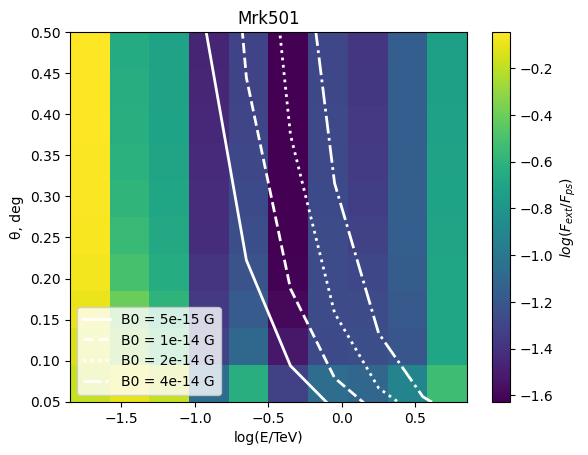

In [19]:
if name == "Mrk421":
    z = 0.03
else:
    z = 0.033
B0 = np.array([5, 10, 20, 40])*10**(-15) # G
lambda_b = 10 # kpc
E_mat = e[:, np.newaxis] # column
B0_mat = B0[np.newaxis, :] # row

E_prime = np.sqrt(E_mat/0.33)*20
delta = 5*10**(-7)*(20/E_prime)**(3/2)*(B0/10**(-18))*(lambda_b)**(1/2)
#delta = 3*10**(-6)*(B0/10**(-18))*(E_prime/20)**(-2)
D_gamma = 40*20/E_prime
tau = 130/D_gamma

#theta_theor = D_gamma*delta/130
#theta_theor = delta/tau
theta_theor = 0.07*(1+z)**(-1/2)*(tau/10)**(-1)*(E_mat/0.1)**(-3/4)*(B0/10**(-14))*(lambda_b)**(1/2)


plt.plot(np.log10(E_mat), theta_theor[:, 0], 'white', linewidth=2, label=f"B0 = {B0_mat[0,0]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 1], 'white', linewidth=2, linestyle='--', label=f"B0 = {B0_mat[0,1]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 2], 'white', linewidth=2, linestyle=':', label=f"B0 = {B0_mat[0,2]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 3], 'white', linewidth=2, linestyle='-.', label=f"B0 = {B0_mat[0,3]:.0e} G")


plt.xlabel("log(E/TeV)")
plt.ylabel("θ, deg")
plt.legend()
plt.title(f"{name}")

plt.imshow(np.log10(flux_ratios), extent=[np.log10(e[0]), np.log10(e[-1]), sigmas_ext[0], sigmas_ext[-1]], aspect='auto', origin='lower')
plt.colorbar(label=r"$log(F_{ext}/F_{ps})$")
#plt.savefig(f'./images/UL_{name}_DC_COMPLETE.png', dpi=600, bbox_inches='tight')
plt.show()

In [20]:
def extr_data_from_csv(filepath):
    tot_datapoints = 10
    data = np.genfromtxt(filepath, delimiter=",", skip_header=1)

    if data.size == 0:
        return np.zeros(tot_datapoints)

    if data.ndim == 1:
        values = data
    else:
        values = data[:, 1] if data.shape[1] > 1 else data[:, 0]

    if len(values) < tot_datapoints:
        values = np.append(values, np.zeros(tot_datapoints - len(values)))

    return values

In [21]:
ext_sim_flux = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux.csv")
ext_sim_flux_up = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux_errup.csv")
ext_sim_flux_down = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux_errdown.csv")

[2.67584927 0.08752453 0.16471153 0.03416476 0.05826811 0.0317574
 0.09539553 0.09871525 0.21464871 0.41183266]
[8.64062551 0.0284994  0.12843822 0.02827665 0.04982898 0.0243947
 0.06561816 0.08821841 0.1955238  0.40298774]
[9.00973992e+01 3.02167332e-03 7.80970785e-02 1.93698772e-02
 4.57781174e-02 2.36369804e-02 5.42958918e-02 7.04545757e-02
 1.62234174e-01 3.85863715e-01]
[9.79594637e+03 3.39680919e-05 2.88745907e-02 9.08918144e-03
 3.87213215e-02 2.34767974e-02 5.33911522e-02 5.51042023e-02
 1.11693465e-01 3.53767679e-01]


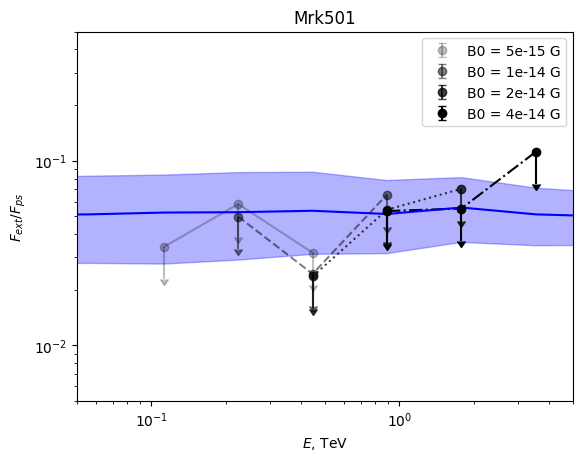

In [24]:
from scipy.interpolate import RegularGridInterpolator
linestyles = ["-", "--", ":", "-."]
starting_relevancy = [10**(-1), 10**(-0.75), 10**(-0.5), 10**(-0.25)]
for i, col_idx in enumerate(range(len(B0))):
    logE = np.log10(E_mat[:, 0])
    theta_curve = theta_theor[:, col_idx]
    
    logE_grid = np.log10(E_mat[:, 0])
    sigma_grid = sigmas_ext
    
    interpolator = RegularGridInterpolator((sigma_grid, logE_grid), 
                                           np.log10(flux_ratios), 
                                           bounds_error=False, 
                                           fill_value=None)
    
    points = np.column_stack([theta_curve, logE])
    flux_ratios_on_curve = 10**interpolator(points)
    print(flux_ratios_on_curve)

    if i==0:
        index_in = 3
        index_fin_rel = 4
    if i==1:
        index_in = 4
        index_fin_rel = 3
    if i==2:
        index_in = 5
        index_fin_rel = 2
    if i==3:
        index_in = 6
        index_fin_rel = 1
    plt.plot(E_mat[index_in:-index_fin_rel, 0], flux_ratios_on_curve[index_in:-index_fin_rel], color="black", alpha=1+0.25*i, linestyle=linestyles[i])
    plt.errorbar(E_mat[index_in:-index_fin_rel, 0], flux_ratios_on_curve[index_in:-index_fin_rel],np.abs(flux_ratios_on_curve[index_in:-index_fin_rel]/3), alpha=0.25+0.25*i, uplims=True, linestyle='none',marker='o', label=f"B0 = {B0[i]:.0e} G",color='black')
plt.plot(E_mat[:, 0], ext_sim_flux, color="blue")
plt.fill_between(E_mat[:, 0], ext_sim_flux_down, ext_sim_flux_up, color='blue', alpha=0.3)
plt.ylim([0.005, 0.5])
plt.xlim([0.05, 5])
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$E$, TeV")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.legend()
plt.title(f"{name}")
plt.savefig(f'./images/UL_{name}_DC_SIM_FINAL.png', dpi=600, bbox_inches='tight')